# 🧠 CRISP-DM Project: Plateforme intelligente de gestion des formations & certifications professionnelles

## 📌 Table of Contents
- [1. Business Understanding](#1-business-understanding)
- [2. Data Understanding](#2-data-understanding)
- [3. Data Preparation](#3-data-preparation)
- [4. Modeling](#4-modeling)
- [5. Evaluation](#5-evaluation)
- [6. Deployment](#6-deployment)

### 1. Business Understanding
<a id="1-business-understanding"></a>

**State of the Art**:  

**Business Objectives (BOs)**:
- BO 1: Identifier les formations à fort potentiel de succès (nombre d’inscriptions élevé) afin d’optimiser la stratégie de création de contenu et l’allocation marketing.
- BO 2: Regrouper les formations similaires afin d’améliorer l’organisation du catalogue et faciliter la recherche des utilisateurs.
- BO 3: Proposer aux apprenants des formations pertinentes selon le sujet, le niveau et la popularité afin d’améliorer l’expérience utilisateur et d’augmenter les inscriptions.

**Data Science Objectives (DSOs)**:
- DSO 1: Construire un modèle de classification capable de prédire si un cours sera populaire ou non à partir de ses caractéristiques.
- DSO 2: Regrouper les formations similaires afin d’améliorer l’organisation du catalogue et faciliter la recherche des utilisateurs.
- DSO 3: Proposer aux apprenants des formations pertinentes selon le sujet, le niveau et la popularité afin d’améliorer l’expérience utilisateur et d’augmenter les inscriptions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Phase 2 : Data Understanding




In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Data Understanding - Load Data
# Load the dataset into a pandas DataFrame.
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv("udemy_courses.csv")
print("✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully!
📊 Shape: 3678 rows × 12 columns


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Data Understanding - Display Head
# Display the first few rows of the DataFrame to get a quick overview.
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("🔍 FIRST 5 ROWS")
print("="*60)
print(df.head())


🔍 FIRST 5 ROWS
   course_id                                       course_title  \
0    1070968                 Ultimate Investment Banking Course   
1    1113822  Complete GST Course & Certification - Grow You...   
2    1006314  Financial Modeling for Business Analysts and C...   
3    1210588  Beginner to Pro - Financial Analysis in Excel ...   
4    1011058       How To Maximize Your Profits Trading Options   

                                                 url  is_paid  price  \
0  https://www.udemy.com/ultimate-investment-bank...     True    200   
1      https://www.udemy.com/goods-and-services-tax/     True     75   
2  https://www.udemy.com/financial-modeling-for-b...     True     45   
3  https://www.udemy.com/complete-excel-finance-c...     True     95   
4  https://www.udemy.com/how-to-maximize-your-pro...     True    200   

   num_subscribers  num_reviews  num_lectures               level  \
0             2147           23            51          All Levels   
1         

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Data Understanding - Display Info
# Display concise summary of the DataFrame, including data types and non-null values.
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("ℹ️  DATASET INFO")
print("="*60)
df.info()


ℹ️  DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3678 entries, 0 to 3677
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   course_id            3678 non-null   int64  
 1   course_title         3678 non-null   object 
 2   url                  3678 non-null   object 
 3   is_paid              3678 non-null   bool   
 4   price                3678 non-null   int64  
 5   num_subscribers      3678 non-null   int64  
 6   num_reviews          3678 non-null   int64  
 7   num_lectures         3678 non-null   int64  
 8   level                3678 non-null   object 
 9   content_duration     3678 non-null   float64
 10  published_timestamp  3678 non-null   object 
 11  subject              3678 non-null   object 
dtypes: bool(1), float64(1), int64(5), object(5)
memory usage: 319.8+ KB


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Data Understanding - Descriptive Statistics
# Display descriptive statistics for numerical columns.
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("📈 DESCRIPTIVE STATISTICS (Numerical Columns)")
print("="*60)
print(df.describe().round(2).T)

print("\n" + "="*60)
print("📝 DESCRIPTIVE STATISTICS (Categorical Columns)")
print("="*60)
print(df.describe(include='object'))


📈 DESCRIPTIVE STATISTICS (Numerical Columns)
                   count       mean        std     min       25%       50%  \
course_id         3678.0  675971.96  343273.16  8324.0  407692.5  687917.0   
price             3678.0      66.05      61.01     0.0      20.0      45.0   
num_subscribers   3678.0    3197.15    9504.12     0.0     111.0     911.5   
num_reviews       3678.0     156.26     935.45     0.0       4.0      18.0   
num_lectures      3678.0      40.11      50.38     0.0      15.0      25.0   
content_duration  3678.0       4.09       6.05     0.0       1.0       2.0   

                        75%        max  
course_id         961355.50  1282064.0  
price                 95.00      200.0  
num_subscribers     2546.00   268923.0  
num_reviews           67.00    27445.0  
num_lectures          45.75      779.0  
content_duration       4.50       78.5  

📝 DESCRIPTIVE STATISTICS (Categorical Columns)
                                             course_title  \
count      

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. Data Understanding - Check Missing Values
# Check for missing values in each column.
# ─────────────────────────────────────────────────────────────────────────────

print("Total missing values :", df.isnull().sum().sum())

if df.isnull().sum().sum() == 0:
    print("✅ Aucune valeur manquante dans le dataset !")
else:
    print("\n⚠️  Détail par colonne :")
    print(df.isnull().sum()[df.isnull().sum() > 0])
    print(f"\n   Pourcentage : {df.isnull().mean().mul(100).round(2)}")

Total missing values : 0
✅ Aucune valeur manquante dans le dataset !


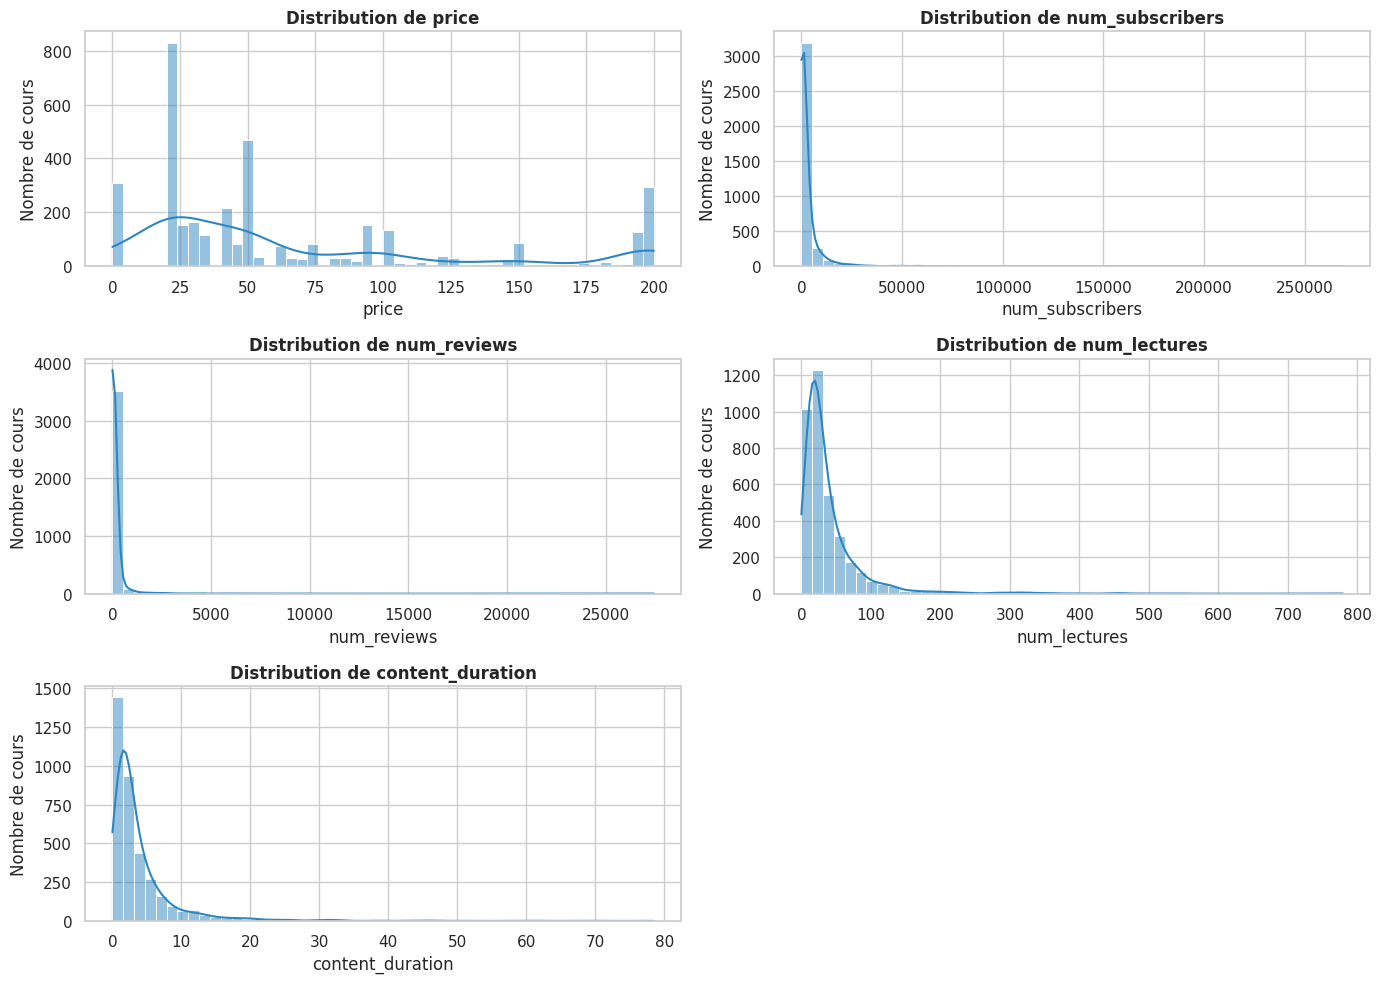

✅ Distributions de toutes les features numériques tracées !
   Fichier sauvegardé : viz_01_numeric_distributions.png


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. Data Understanding - Data Visualization
# Visualize distributions, relationships, and patterns in the data.
# ─────────────────────────────────────────────────────────────────────────────

# ── Style global ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
FIGSIZE = (12, 5)
COLOR_MAIN = "#4C72B0"
# ─────────────────────────────────────────────────────────────────────────────
# 6.1 Distribution of All Numerical Features (Simple Histplot)
# ─────────────────────────────────────────────────────────────────────────────

numeric_features = ['price', 'num_subscribers', 'num_reviews',
                    'num_lectures', 'content_duration']

plt.figure(figsize=(14, 10))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], bins=50, kde=True, color="#2E86C1")
    plt.title(f"Distribution de {col}", fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel("Nombre de cours")

plt.tight_layout()
plt.savefig("viz_01_numeric_distributions.png", dpi=180, bbox_inches='tight')
plt.show()

print("✅ Distributions de toutes les features numériques tracées !")
print("   Fichier sauvegardé : viz_01_numeric_distributions.png")

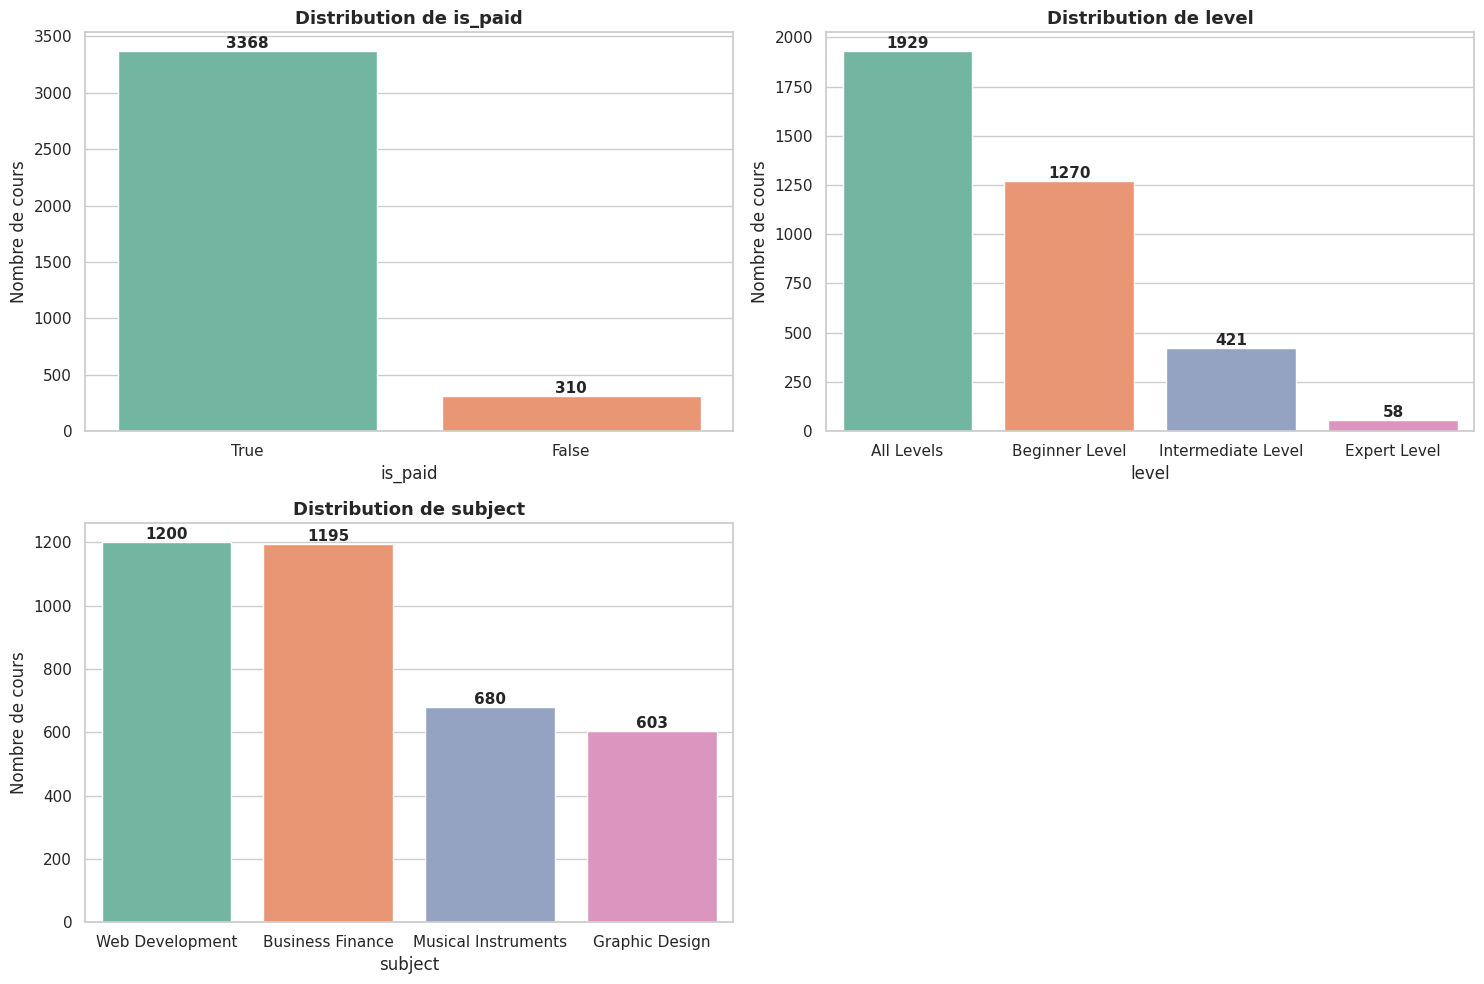

✅ Toutes les distributions catégorielles ont été tracées !
   Fichier sauvegardé : viz_02_all_categorical_distributions.png


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.2 Countplot - Distribution de toutes les features catégorielles
# ─────────────────────────────────────────────────────────────────────────────

categorical_features = ['is_paid', 'level', 'subject']

plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)

    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette="Set2", edgecolor='white')

    plt.title(f"Distribution de {col}", fontsize=13, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel("Nombre de cours")

    # Ajouter les valeurs sur les barres
    for p in plt.gca().patches:
        plt.gca().annotate(f'{int(p.get_height())}',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("viz_02_all_categorical_distributions.png", dpi=180, bbox_inches='tight')
plt.show()

print("✅ Toutes les distributions catégorielles ont été tracées !")
print("   Fichier sauvegardé : viz_02_all_categorical_distributions.png")

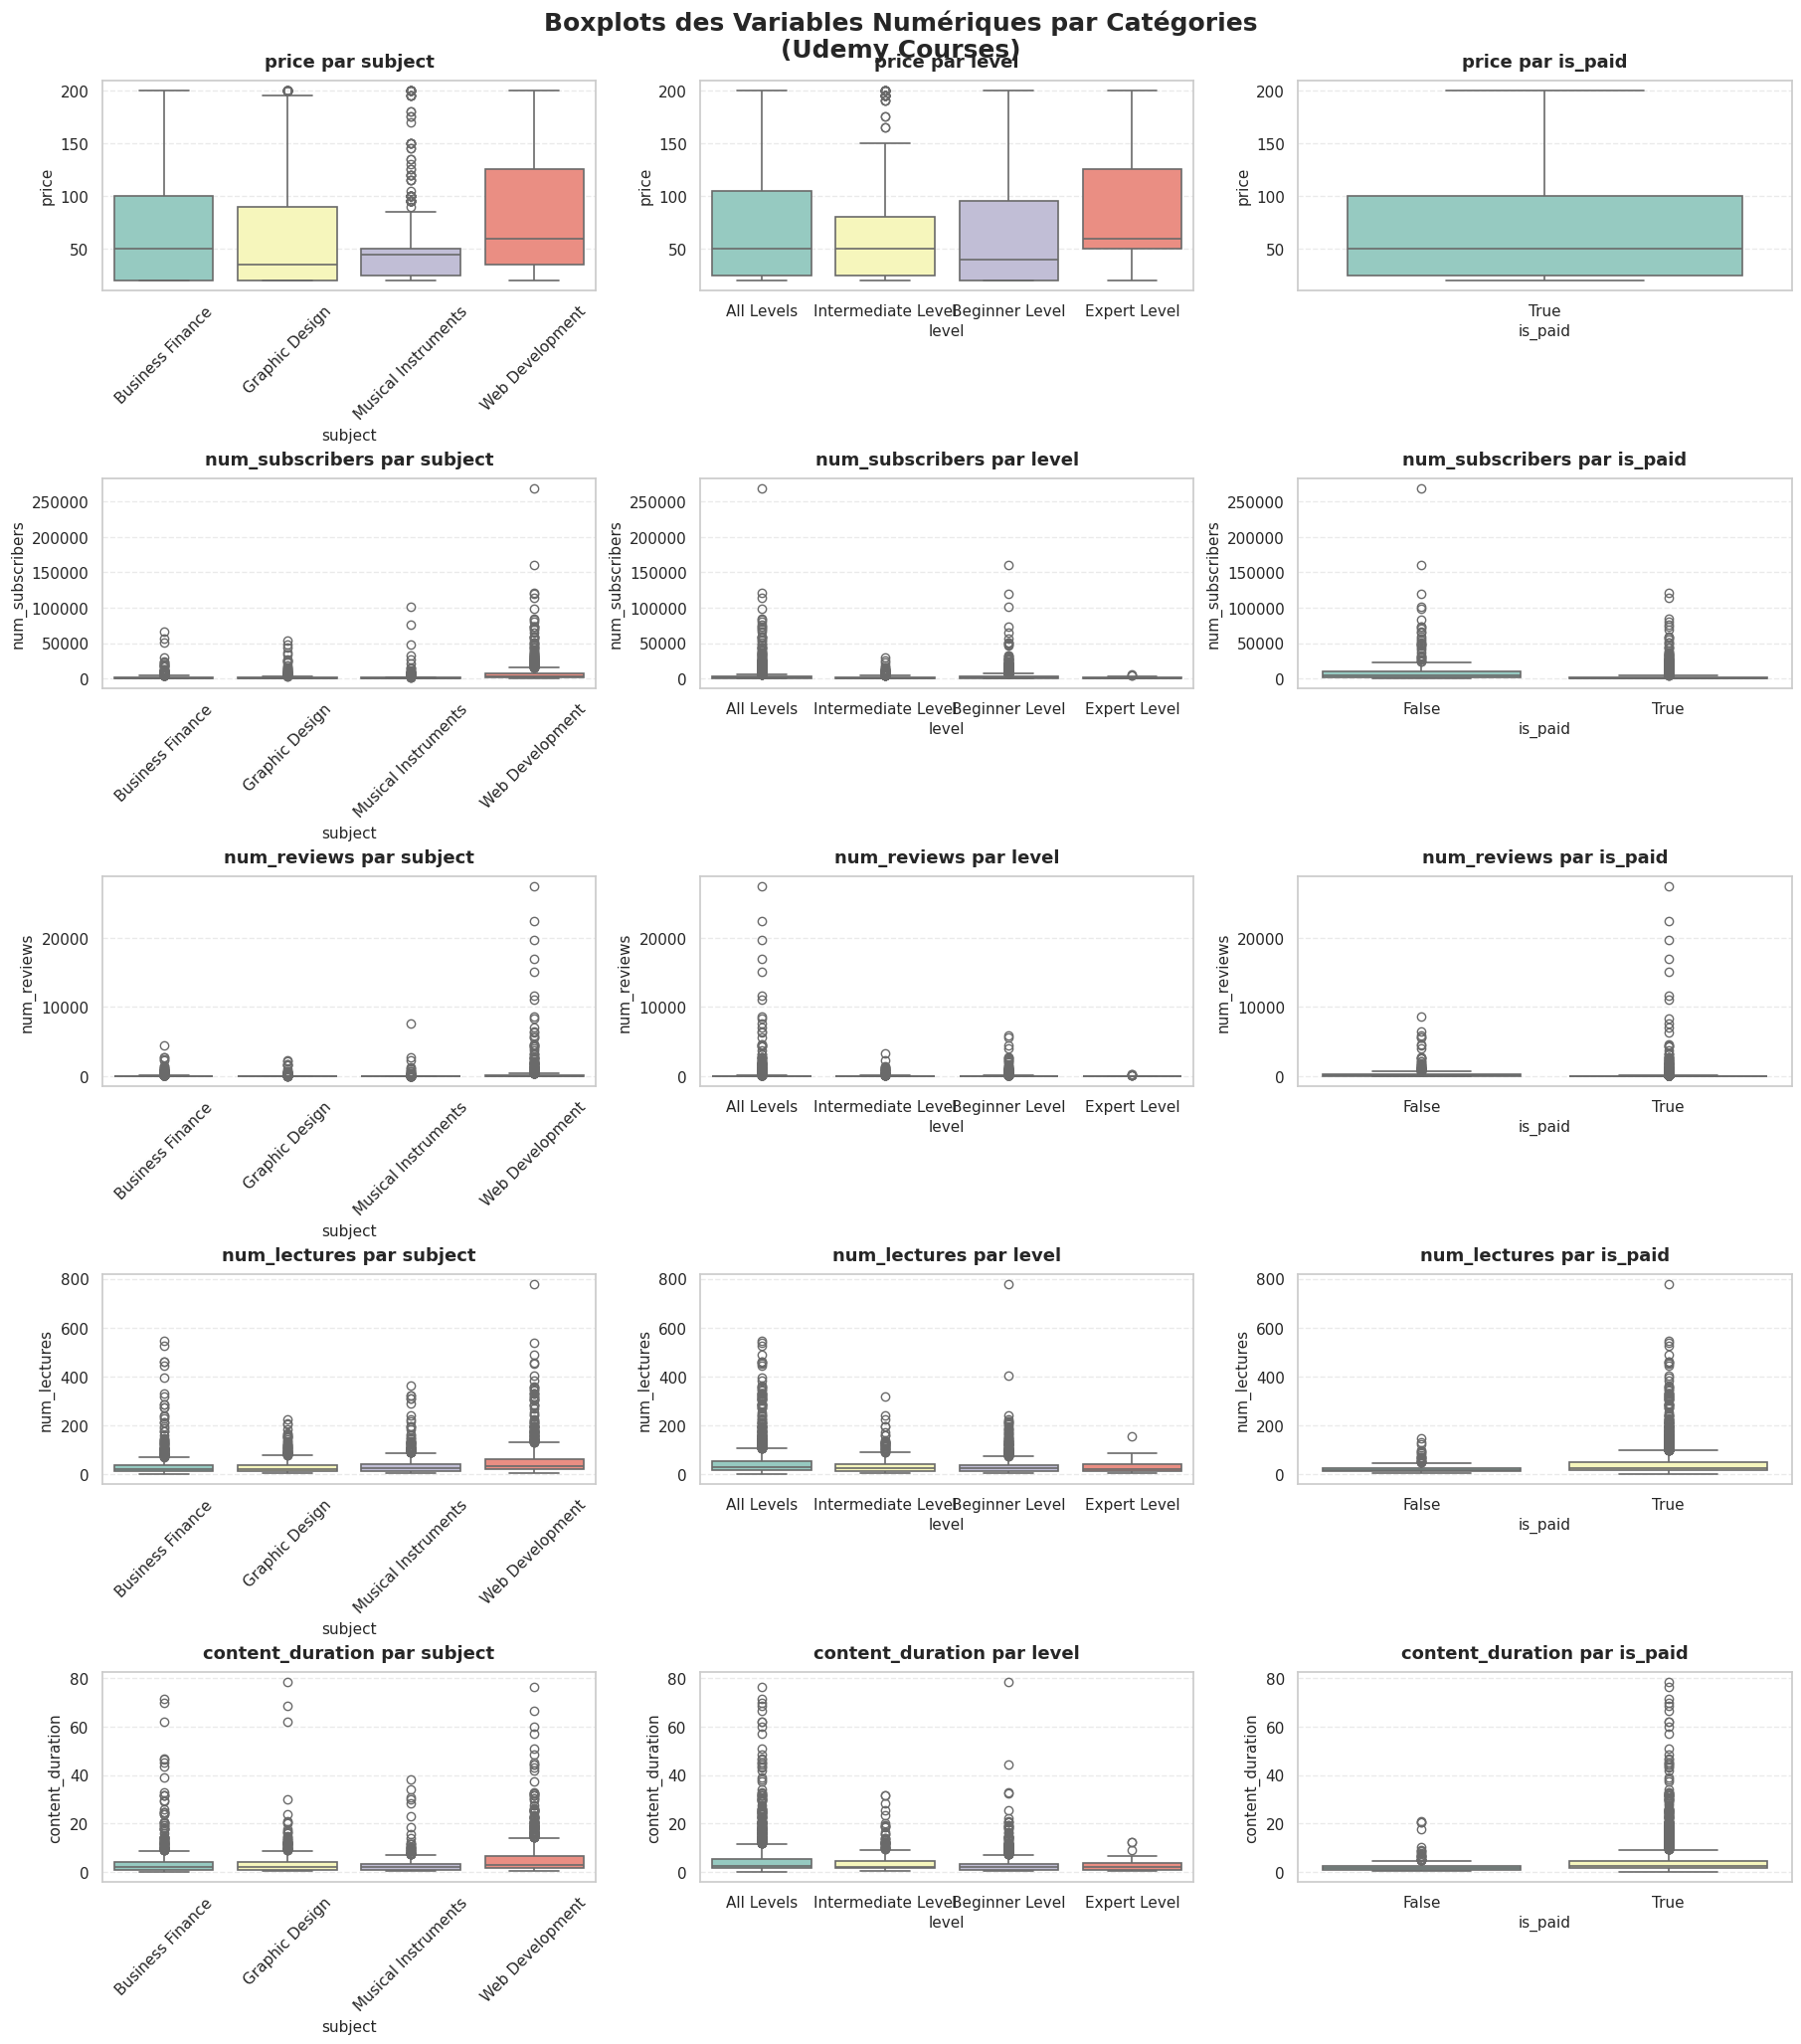

✅ Boxplots clairs et lisibles générés avec succès !
   Fichier sauvegardé : viz_05_clear_boxplots.png


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.5 Boxplots Clairs et Lisibles - Analyse par Catégorie
# ─────────────────────────────────────────────────────────────────────────────

numeric_cols = ['price', 'num_subscribers', 'num_reviews', 'num_lectures', 'content_duration']
cat_cols = ['subject', 'level', 'is_paid']

# Création d'une figure avec une meilleure mise en page
fig, axes = plt.subplots(len(numeric_cols), len(cat_cols),
                         figsize=(18, 4 * len(numeric_cols)),
                         constrained_layout=True)

fig.suptitle("Boxplots des Variables Numériques par Catégories\n(Udemy Courses)",
             fontsize=18, fontweight='bold', y=1.02)

for i, num_col in enumerate(numeric_cols):
    for j, cat_col in enumerate(cat_cols):
        ax = axes[i, j]

        # Filtrer les cours payants pour le prix (plus logique)
        plot_data = df[df['is_paid'] == True] if num_col == 'price' else df

        sns.boxplot(data=plot_data, x=cat_col, y=num_col,
                    palette="Set3", ax=ax, linewidth=1.2)

        # Améliorations de lisibilité
        ax.set_title(f"{num_col} par {cat_col}", fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel(cat_col, fontsize=11)
        ax.set_ylabel(num_col, fontsize=11)

        # Rotation des labels pour éviter le chevauchement
        if cat_col == 'subject':
            ax.tick_params(axis='x', rotation=45)

        # Grille légère pour mieux lire les valeurs
        ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.savefig("viz_05_clear_boxplots.png", dpi=200, bbox_inches='tight')
plt.show()

print("✅ Boxplots clairs et lisibles générés avec succès !")
print("   Fichier sauvegardé : viz_05_clear_boxplots.png")

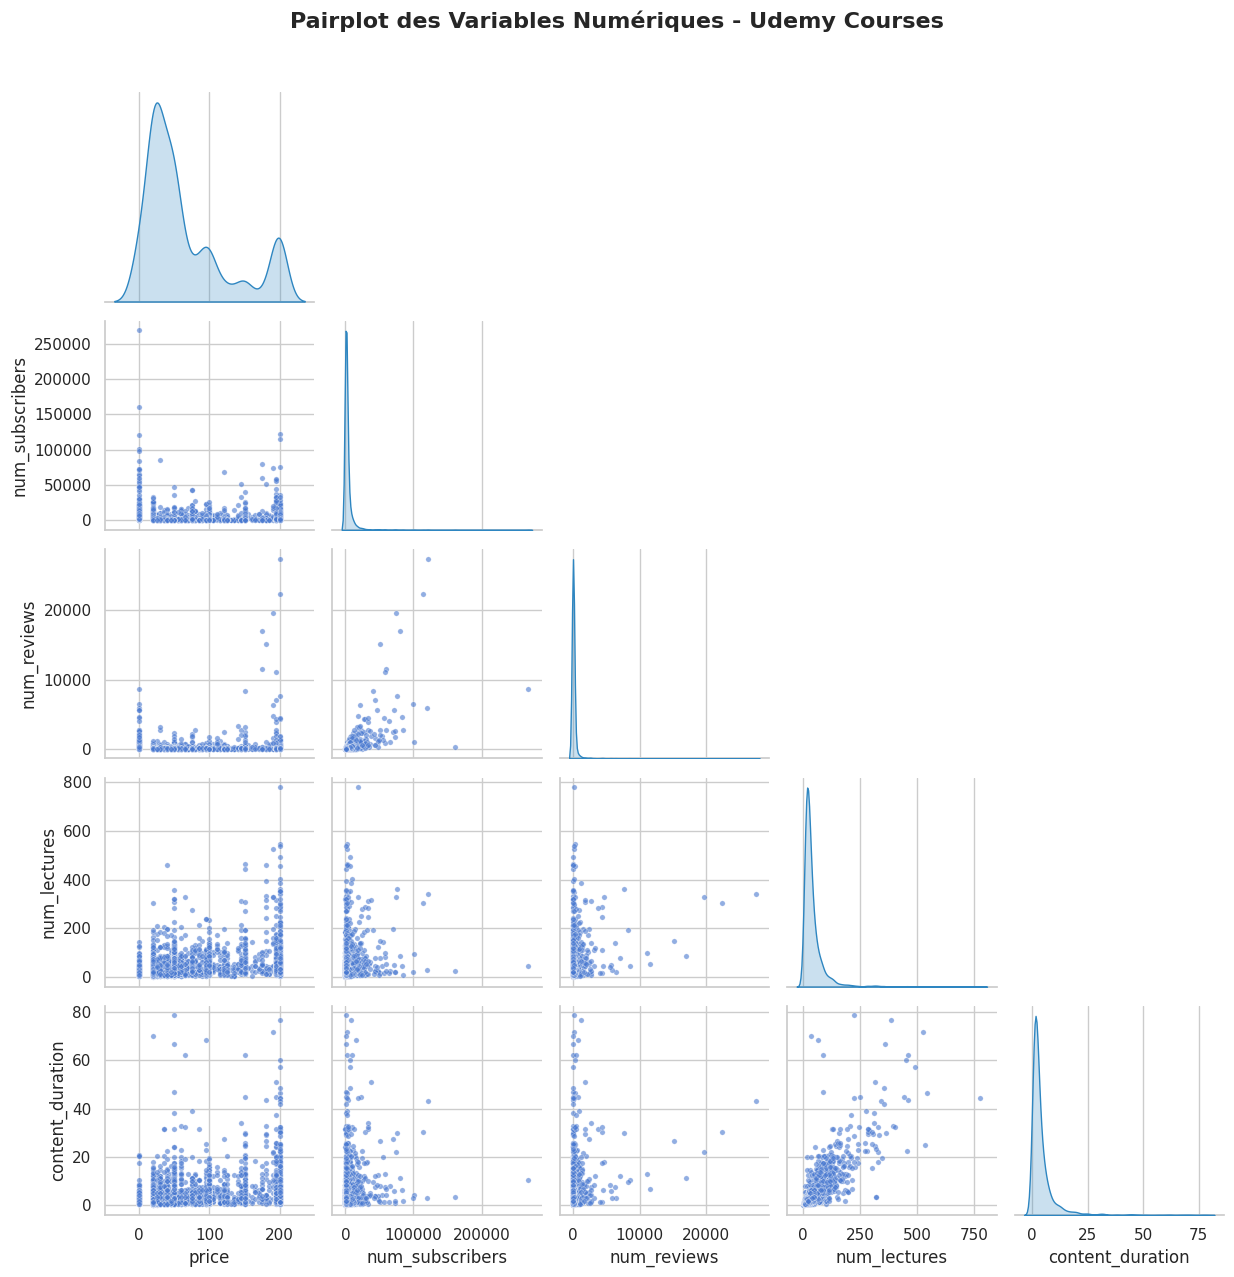

✅ Pairplot de toutes les features numériques généré avec succès !
   Fichier sauvegardé : viz_10_pairplot_numeric_features.png


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.10 Pairplot - All Numerical Features
# ─────────────────────────────────────────────────────────────────────────────

import seaborn as sns
import matplotlib.pyplot as plt

# Sélection des colonnes numériques
numeric_cols = ['price', 'num_subscribers', 'num_reviews',
                'num_lectures', 'content_duration']

# Création du Pairplot
# Supprimer plt.figure(figsize=(14, 12)) — inutile ici
g = sns.pairplot(df[numeric_cols],
                 diag_kind='kde',
                 corner=True,
                 plot_kws={'alpha': 0.6, 's': 15},
                 diag_kws={'color': '#2E86C1'})



g.fig.suptitle("Pairplot des Variables Numériques - Udemy Courses",
               fontsize=16, fontweight='bold', y=1.02)

# Amélioration de la lisibilité
plt.tight_layout()

# Sauvegarde en haute qualité
plt.savefig("viz_10_pairplot_numeric_features.png", dpi=200, bbox_inches='tight')
plt.show()

print("✅ Pairplot de toutes les features numériques généré avec succès !")
print("   Fichier sauvegardé : viz_10_pairplot_numeric_features.png")

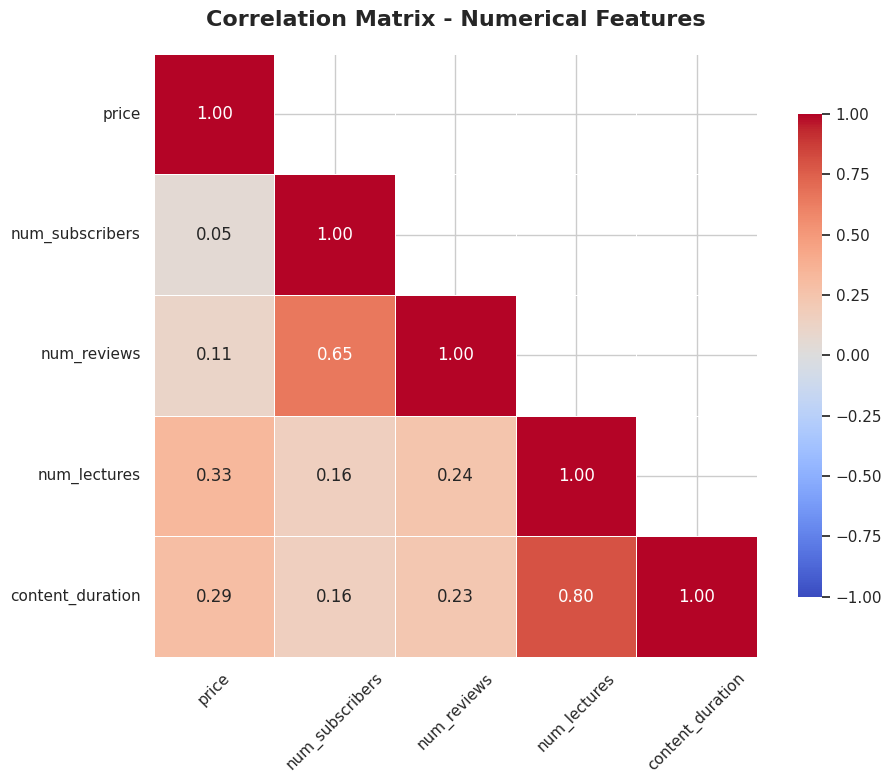

✅ Correlation Heatmap générée avec succès !
   Fichier sauvegardé : viz_09_correlation_heatmap.png


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.9 Correlation Heatmap - Version améliorée et claire
# ─────────────────────────────────────────────────────────────────────────────

num_cols = ['price', 'num_subscribers', 'num_reviews',
            'num_lectures', 'content_duration']

# Calcul de la matrice de corrélation
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))

# Mask pour la partie supérieure (triangulaire)
# Pour masquer seulement le triangle supérieur SANS la diagonale :
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            mask=mask,
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            square=True,           # Cases carrées (plus esthétique)
            cbar_kws={"shrink": 0.8})

plt.title("Correlation Matrix - Numerical Features",
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("viz_09_correlation_heatmap.png", dpi=200, bbox_inches='tight')
plt.show()

print("✅ Correlation Heatmap générée avec succès !")
print("   Fichier sauvegardé : viz_09_correlation_heatmap.png")

## Phase 3 : Data Preparation


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder , LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. DATA PREPARATION - Version complète avec visualisations
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*75)
print("🔧 7. DATA PREPARATION")
print("="*75)
# ====================== 1. Copie des données ======================
df = pd.read_csv("udemy_courses.csv")   # ← adapter le chemin si nécessaire
df_prep = df.copy()
print("✅ Copie du dataframe créée : df_prep")


🔧 7. DATA PREPARATION
✅ Copie du dataframe créée : df_prep


In [14]:
# ====================== 2. Suppression des colonnes inutiles ======================
columns_to_drop = ['course_id', 'url', 'published_timestamp', 'course_title']
df_prep.drop(columns=columns_to_drop, errors='ignore', inplace=True)
print(f"✅ Colonnes supprimées : {columns_to_drop}")

✅ Colonnes supprimées : ['course_id', 'url', 'published_timestamp', 'course_title']


In [15]:
# ====================== 3. Gestion des valeurs manquantes ======================
print("\n→ Gestion des valeurs manquantes...")
missing = df_prep.isnull().sum().sum()
if missing == 0:
    print("✅ Aucune valeur manquante trouvée.")
else:
    print(f"⚠️  {missing} valeurs manquantes détectées.")
    for col in df_prep.columns:
        if df_prep[col].dtype == 'object':
            df_prep[col].fillna(df_prep[col].mode()[0], inplace=True)
        else:
            df_prep[col].fillna(df_prep[col].median(), inplace=True)
    print("   → Valeurs manquantes traitées (médiane / mode).")


→ Gestion des valeurs manquantes...
✅ Aucune valeur manquante trouvée.



📦 7.4 GESTION DES OUTLIERS (IQR + Capping) + VISUALISATION
🔍 Détection des outliers (Méthode IQR) :

→ price                :     0 outliers ( 0.00%)
→ num_subscribers      :   433 outliers (11.77%)
→ num_reviews          :   494 outliers (13.43%)
→ num_lectures         :   293 outliers ( 7.97%)
→ content_duration     :   313 outliers ( 8.51%)

------------------------------------------------------------
         Feature  Outliers     %    Lower   Upper
           price         0  0.00   -92.50  207.50
 num_subscribers       433 11.77 -3541.50 6198.50
     num_reviews       494 13.43   -90.50  161.50
    num_lectures       293  7.97   -31.12   91.88
content_duration       313  8.51    -4.25    9.75

🔧 Application du Capping (Winsorization)...
✅ Capping appliqué avec succès sur toutes les features numériques.

📊 Création des boxplots APRÈS traitement...


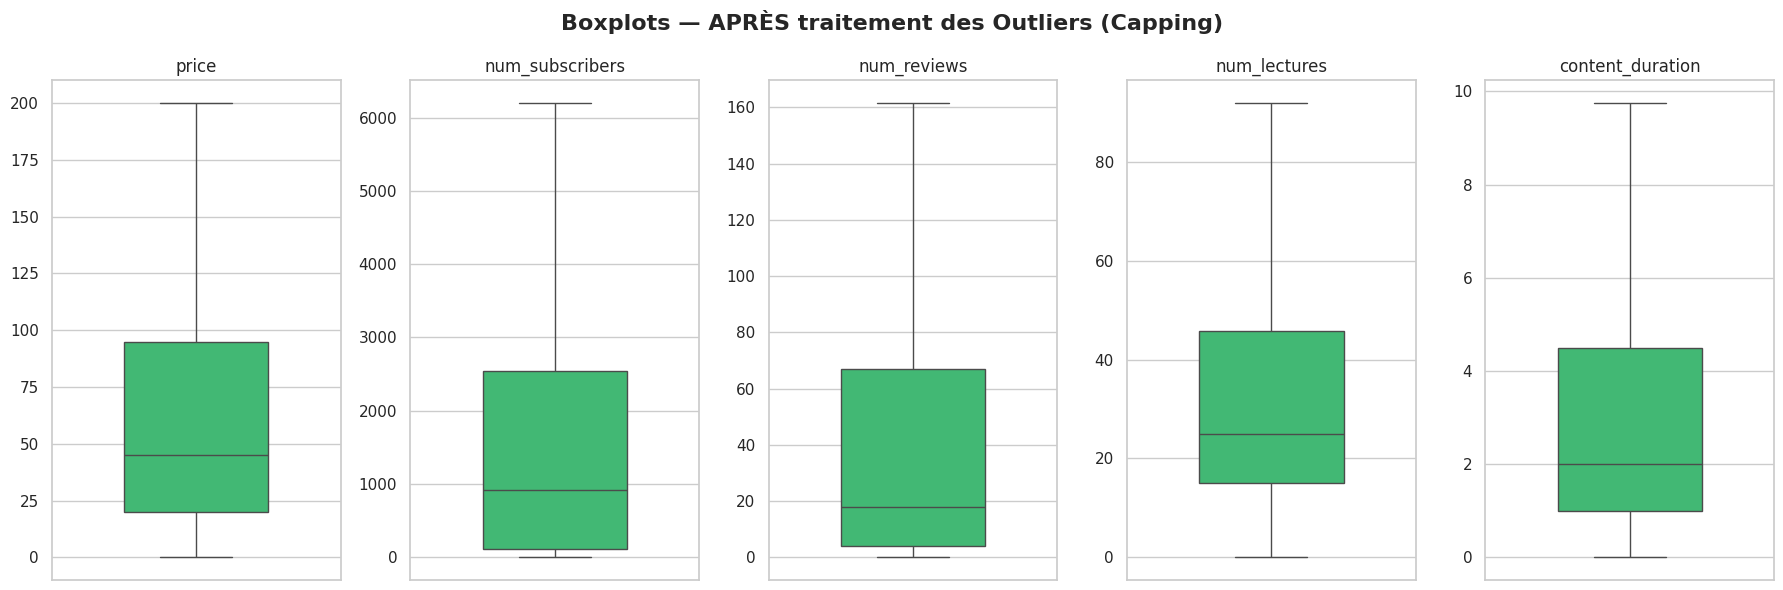


✅ Gestion des outliers + visualisation terminée !


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 7.4 Gestion des Outliers + Visualisation (Boxplots Avant / Après)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("📦 7.4 GESTION DES OUTLIERS (IQR + Capping) + VISUALISATION")
print("="*70)

numeric_cols = ['price', 'num_subscribers', 'num_reviews',
                'num_lectures', 'content_duration']

# ====================== 1. Détection des Outliers ======================
print("🔍 Détection des outliers (Méthode IQR) :\n")

outlier_summary = []
for col in numeric_cols:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df_prep[col] < lower) | (df_prep[col] > upper)).sum()
    pct = round(n_outliers / len(df_prep) * 100, 2)

    outlier_summary.append({'Feature': col, 'Outliers': n_outliers, '%': pct,
                            'Lower': round(lower,2), 'Upper': round(upper,2)})

    print(f"→ {col:20} : {n_outliers:5d} outliers ({pct:5.2f}%)")

print("\n" + "-"*60)
print(pd.DataFrame(outlier_summary).to_string(index=False))

# ====================== 3. Traitement des Outliers (Capping) ======================
print("\n🔧 Application du Capping (Winsorization)...")

for col in numeric_cols:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_prep[col] = df_prep[col].clip(lower=lower, upper=upper)

print("✅ Capping appliqué avec succès sur toutes les features numériques.")

# ====================== 4. Visualisation APRÈS traitement ======================
print("\n📊 Création des boxplots APRÈS traitement...")

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 6))
fig.suptitle("Boxplots — APRÈS traitement des Outliers (Capping)",
             fontsize=16, fontweight='bold')

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_prep[col], ax=ax, color='#2ECC71', width=0.5)
    ax.set_title(col, fontsize=12)
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig("outliers_boxplots_after.png", dpi=200, bbox_inches='tight')
plt.show()

print("\n✅ Gestion des outliers + visualisation terminée !")

In [17]:
# ====================== 4. Feature Engineering ======================
print("\n→ Feature Engineering...")

df_prep['reviews_per_subscriber'] = df_prep['num_reviews'] / df_prep['num_subscribers'].replace(0, np.nan)
df_prep['lectures_per_hour']      = df_prep['num_lectures'] / df_prep['content_duration'].replace(0, np.nan)

print("   → Nouvelles features créées : reviews_per_subscriber, lectures_per_hour")


→ Feature Engineering...
   → Nouvelles features créées : reviews_per_subscriber, lectures_per_hour


In [18]:
# ====================== 5. Séparation X et y ======================
target = 'num_subscribers'
X = df_prep.drop(columns=[target])
threshold = df_prep['num_subscribers'].median()
y = (df_prep['num_subscribers'] >= threshold).astype(int)
print(f"Seuil (médiane) : {threshold:,.0f} — classes : {y.value_counts().to_dict()}")

# ✅ Sauvegarder les colonnes catégorielles ICI (avant split)
X_cat_before_enc = X[['subject', 'level']].copy()

print(f"\n✅ Séparation effectuée → Target = '{target}'")

Seuil (médiane) : 912 — classes : {1: 1839, 0: 1839}

✅ Séparation effectuée → Target = 'num_subscribers'


In [19]:
# ====================== 6. Train / Validation / Test Split ======================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ✅ Sauvegarde ICI — juste après le split, avant tout encodage
X_train_before_enc = X_train[['subject', 'level']].copy()
is_paid_before     = X_train['is_paid'].copy()

print(f"📊 Split terminé :")
print(f"   Train      : {X_train.shape[0]:,} échantillons")
print(f"   Validation : {X_valid.shape[0]:,} échantillons")
print(f"   Test       : {X_test.shape[0]:,} échantillons")

📊 Split terminé :
   Train      : 2,574 échantillons
   Validation : 552 échantillons
   Test       : 552 échantillons


In [20]:
# ====================== 7. Encodage ======================
cat_cols   = ['subject', 'level']
label_cols = ['is_paid']

# Sauvegarde AVANT encodage pour visualisation
X_train_before_enc = X_train[cat_cols].copy()
is_paid_before     = X_train['is_paid'].copy()

# One-Hot Encoding
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_valid = pd.get_dummies(X_valid, columns=cat_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)

X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
print("\n✅ One-Hot Encoding appliqué sur :", cat_cols)

# Label Encoding sur is_paid
for col in label_cols:
    if col in X_train.columns:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col])
        X_valid[col] = le.transform(X_valid[col])
        X_test[col]  = le.transform(X_test[col])
print("✅ Label Encoding appliqué sur :", label_cols)


✅ One-Hot Encoding appliqué sur : ['subject', 'level']
✅ Label Encoding appliqué sur : ['is_paid']


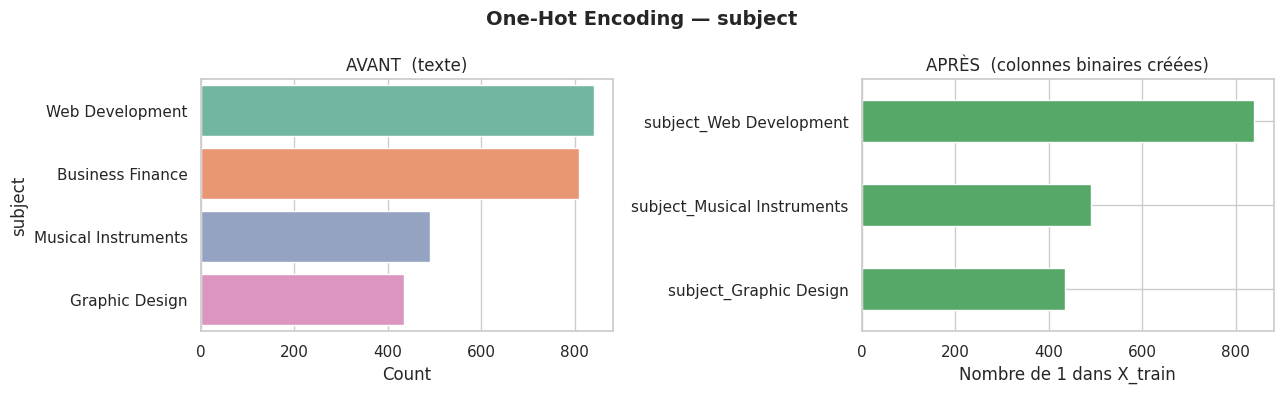

✅ Plot saved: dp_viz_02_ohe.png


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# 📊 VISUALISATION — Avant / Après One-Hot Encoding
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("One-Hot Encoding — subject", fontsize=14, fontweight='bold')

# AVANT : valeurs texte originales
order_subj = X_train_before_enc['subject'].value_counts().index
sns.countplot(y=X_train_before_enc['subject'], order=order_subj,
              palette='Set2', edgecolor='white', ax=axes[0])
axes[0].set_title("AVANT  (texte)")
axes[0].set_xlabel("Count")

# APRÈS : colonnes OHE créées
ohe_cols = [c for c in X_train.columns if c.startswith('subject_')]
X_train[ohe_cols].sum().sort_values().plot(
    kind='barh', color='#55A868', edgecolor='white', ax=axes[1])
axes[1].set_title("APRÈS  (colonnes binaires créées)")
axes[1].set_xlabel("Nombre de 1 dans X_train")

plt.tight_layout()
plt.savefig("dp_viz_02_ohe.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: dp_viz_02_ohe.png")

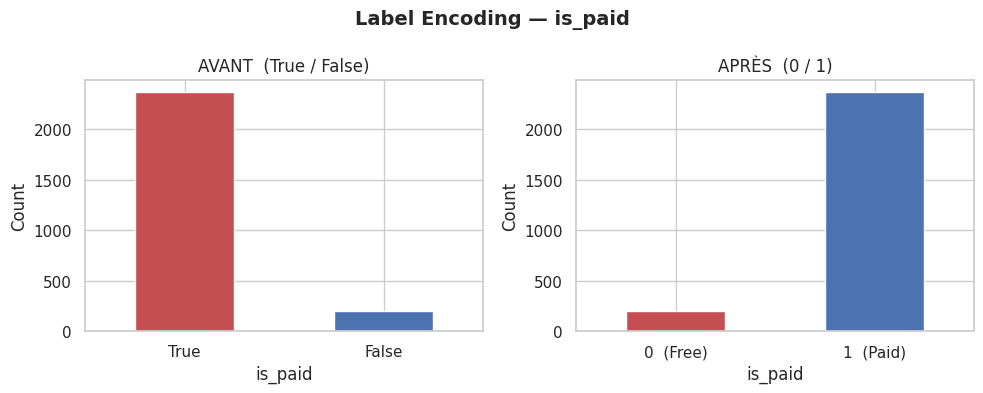

✅ Plot saved: dp_viz_03_label_enc.png


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# 📊 VISUALISATION — Avant / Après Label Encoding (is_paid)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Label Encoding — is_paid", fontsize=14, fontweight='bold')

# AVANT : True / False
is_paid_before.value_counts().plot(
    kind='bar', color=['#C44E52', '#4C72B0'], edgecolor='white', ax=axes[0])
axes[0].set_title("AVANT  (True / False)")
axes[0].set_xticklabels(['True', 'False'], rotation=0)
axes[0].set_ylabel("Count")

# APRÈS : 0 / 1
pd.Series(X_train['is_paid']).value_counts().sort_index().plot(
    kind='bar', color=['#C44E52', '#4C72B0'], edgecolor='white', ax=axes[1])
axes[1].set_title("APRÈS  (0 / 1)")
axes[1].set_xticklabels(['0  (Free)', '1  (Paid)'], rotation=0)
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("dp_viz_03_label_enc.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: dp_viz_03_label_enc.png")

In [23]:
# ====================== 8. Transformation Log + Normalisation ======================

# Colonnes numériques à traiter
num_cols = ['price', 'num_reviews', 'num_lectures', 'content_duration',
            'reviews_per_subscriber', 'lectures_per_hour']
num_cols = [c for c in num_cols if c in X_train.columns]

# Colonnes sur lesquelles on applique log1p (features très skewées)
log_cols = ['price', 'num_reviews', 'num_lectures', 'content_duration']
log_cols = [c for c in log_cols if c in X_train.columns]

print(f"Colonnes pour Log1p : {log_cols}")
print(f"Colonnes pour StandardScaler : {num_cols}\n")

# ── Sauvegarde AVANT transformation (pour visualisation après) ─────────────
X_train_before = X_train[num_cols].copy()

# ── 1. Transformation Log (log1p) ───────────────────────────────────────────
for col in log_cols:
    # Option de sécurité : remplacer les valeurs négatives par 0 (rare mais possible)
    X_train[col] = np.log1p(np.maximum(X_train[col], 0))
    X_valid[col] = np.log1p(np.maximum(X_valid[col], 0))
    X_test[col]  = np.log1p(np.maximum(X_test[col], 0))

print("✅ Transformation log1p appliquée sur :", log_cols)

# ── Sauvegarde APRÈS log (avant scaling) ─────────────────────────────────────
X_train_after_log = X_train[num_cols].copy()

# ── 2. Standardisation (StandardScaler) ─────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_valid[num_cols] = scaler.transform(X_valid[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("✅ StandardScaler appliqué sur toutes les colonnes numériques :", num_cols)

Colonnes pour Log1p : ['price', 'num_reviews', 'num_lectures', 'content_duration']
Colonnes pour StandardScaler : ['price', 'num_reviews', 'num_lectures', 'content_duration', 'reviews_per_subscriber', 'lectures_per_hour']

✅ Transformation log1p appliquée sur : ['price', 'num_reviews', 'num_lectures', 'content_duration']
✅ StandardScaler appliqué sur toutes les colonnes numériques : ['price', 'num_reviews', 'num_lectures', 'content_duration', 'reviews_per_subscriber', 'lectures_per_hour']


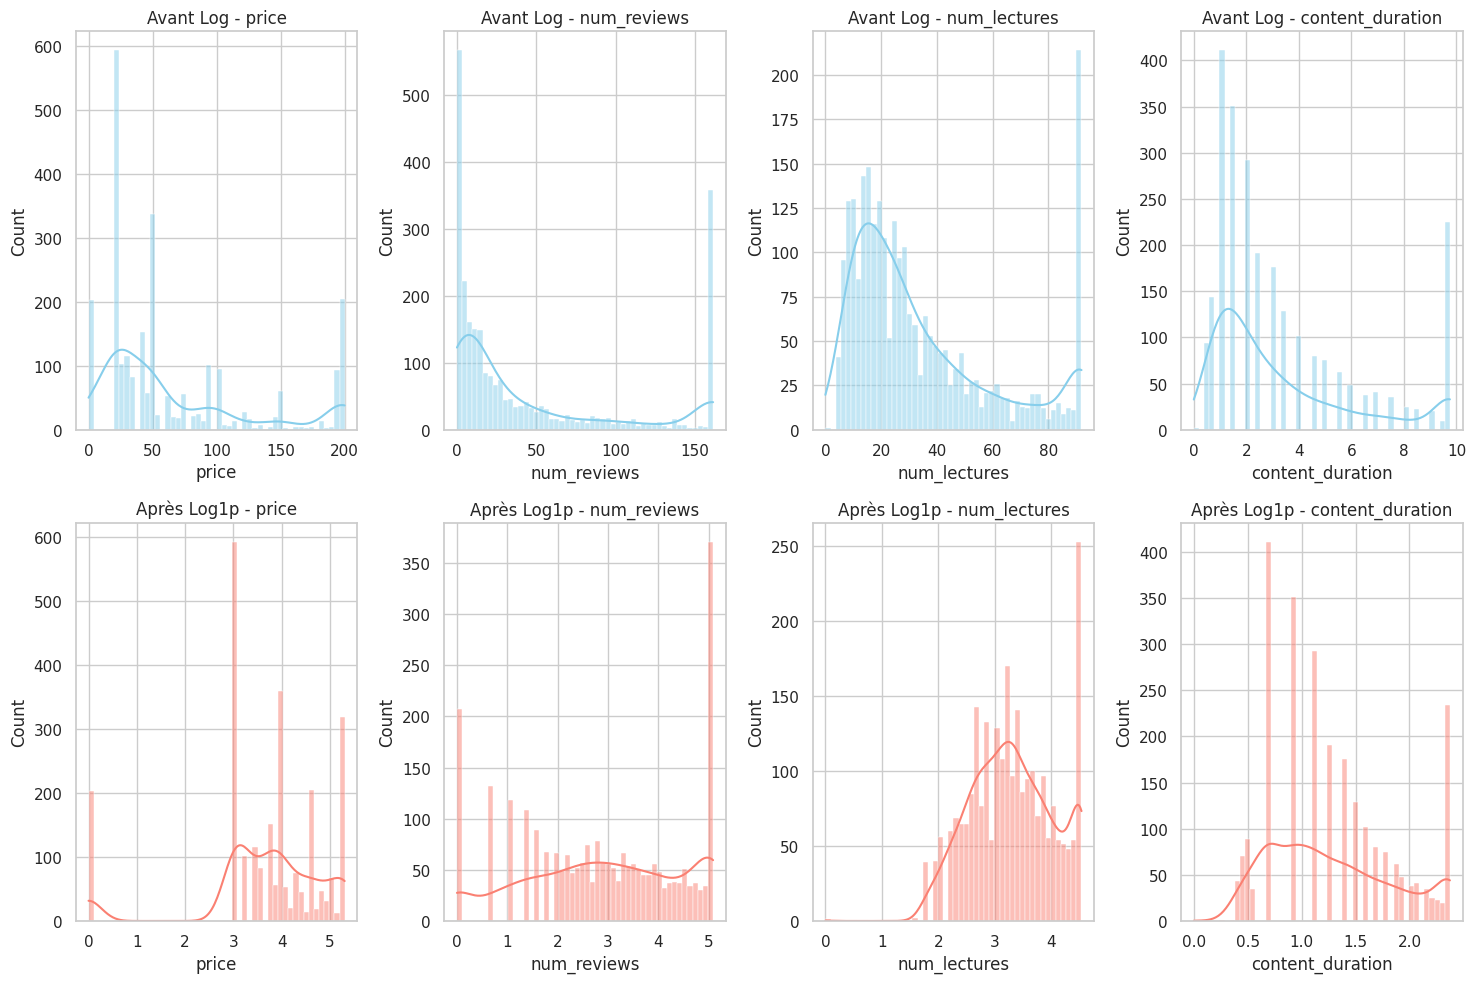

✅ Visualisation Avant/Après Log sauvegardée !


In [24]:
# ====================== Visualisation Avant / Après Log ======================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for i, col in enumerate(log_cols, 1):
    plt.subplot(2, len(log_cols), i)
    sns.histplot(X_train_before[col], bins=50, kde=True, color='skyblue')
    plt.title(f"Avant Log - {col}")

    plt.subplot(2, len(log_cols), i + len(log_cols))
    sns.histplot(X_train_after_log[col], bins=50, kde=True, color='salmon')
    plt.title(f"Après Log1p - {col}")

plt.tight_layout()
plt.savefig("viz_02_log_transformation_effect.png", dpi=180, bbox_inches='tight')
plt.show()

print("✅ Visualisation Avant/Après Log sauvegardée !")

   Colonnes utilisées pour la PCA : ['price', 'num_reviews', 'num_lectures', 'content_duration', 'reviews_per_subscriber', 'lectures_per_hour']

✅ PCA terminée !
   Features avant PCA     : 6
   Composantes pour 95%   : 5 (variance cumulée = 99.5%)


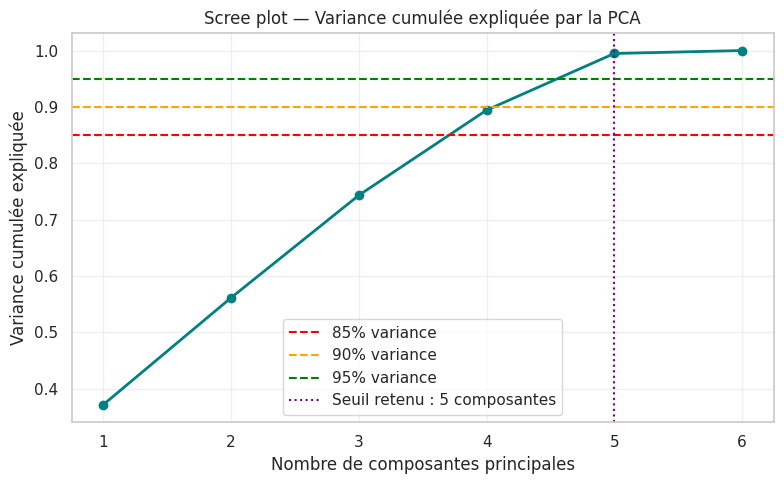

✅ Plot 1 saved: dp_pca_scree.png

   Shape avant PCA : (2574, 6)  →  après PCA : (2574, 5)


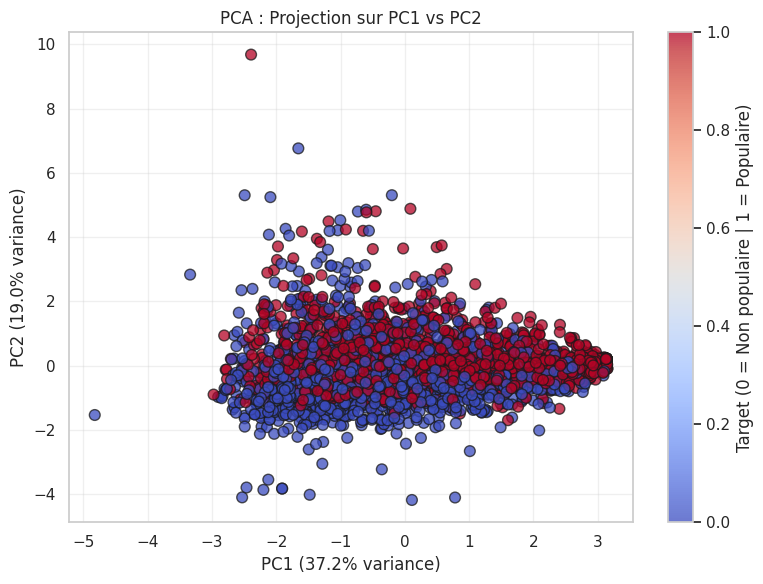

✅ Plot 2 saved: dp_pca_scatter_pc1_pc2.png


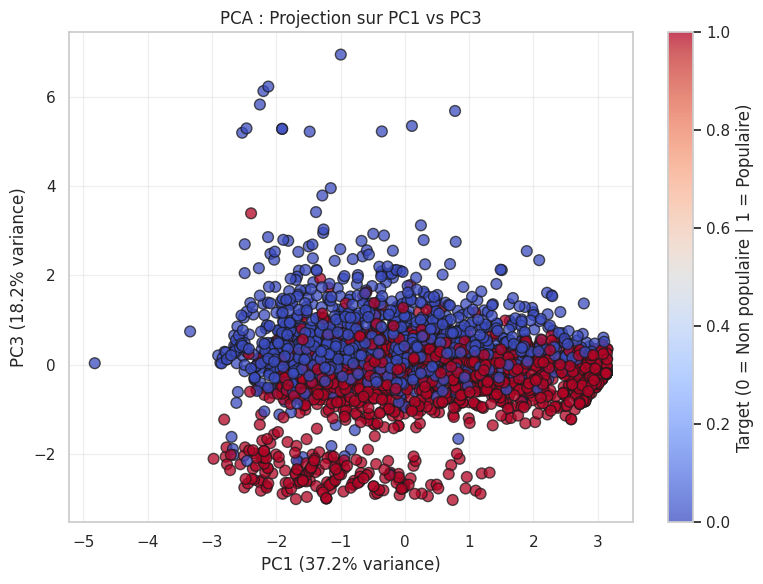

✅ Plot 3 saved: dp_pca_scatter_pc1_pc3.png


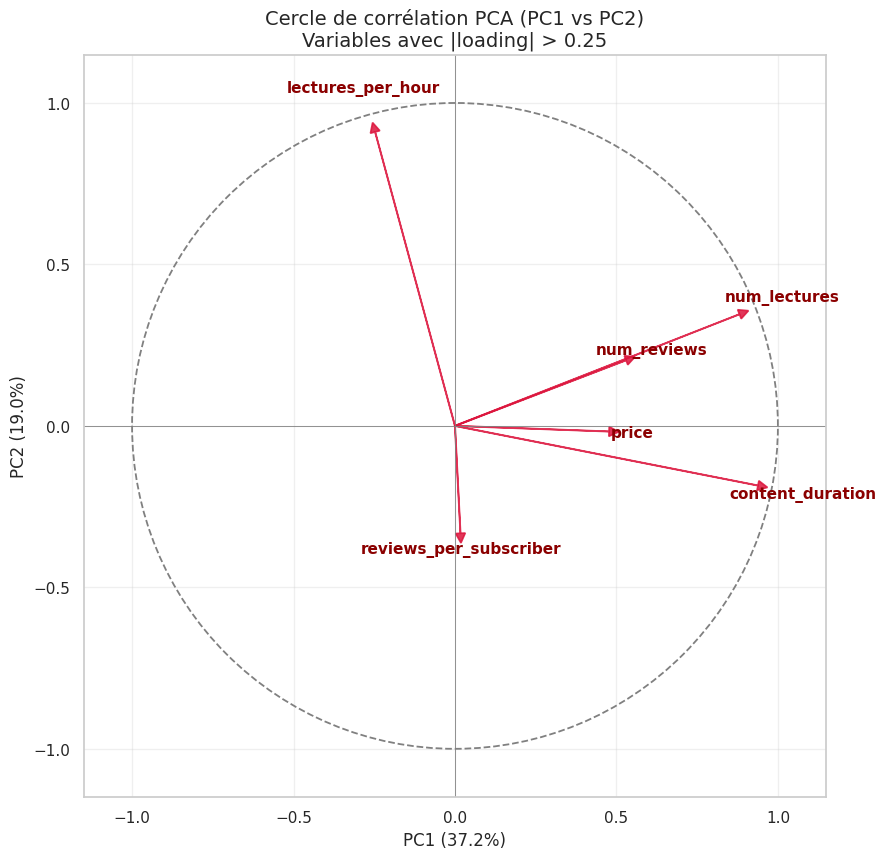

✅ Plot 4 saved: dp_pca_cercle_correlation.png

💡 INTERPRÉTATION PCA

  → 5 composantes principales capturent 99.5% de la variance totale.
  → Réduction : 6 variables → 5 composantes.

  PC1 (37.2% de variance) : axe dominant
  PC2 (19.0% de variance) : axe secondaire

Regarde le cercle de corrélation pour comprendre quelles variables contribuent le plus à chaque axe.



In [25]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# 9. PCA — Réduction de dimensionnalité
# Appliquée uniquement sur les features numériques continues
# ─────────────────────────────────────────────────────────────────────────────

# ── 0. Colonnes numériques continues pour la PCA ─────────────────────────────
pca_cols = [
    'price',
    'num_reviews',
    'num_lectures',
    'content_duration',
    'reviews_per_subscriber',
    'lectures_per_hour'
]
pca_cols = [c for c in pca_cols if c in X_train.columns]
print(f"   Colonnes utilisées pour la PCA : {pca_cols}")

# ── 1. Imputation des NaN éventuels (reviews_per_subscriber / lectures_per_hour) ──
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train[pca_cols])
X_valid_imp = imputer.transform(X_valid[pca_cols])
X_test_imp  = imputer.transform(X_test[pca_cols])

# ── 2. PCA complète pour trouver le bon nombre de composantes ────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_train_imp)

explained  = pca_full.explained_variance_ratio_
cum_var    = np.cumsum(explained)

# Nombre de composantes pour atteindre 95% de variance expliquée
n_components = int(np.argmax(cum_var >= 0.95) + 1)

print(f"\n✅ PCA terminée !")
print(f"   Features avant PCA     : {len(pca_cols)}")
print(f"   Composantes pour 95%   : {n_components} (variance cumulée = {cum_var[n_components-1]:.1%})")

# ─────────────────────────────────────────────────────────────────────────────
# 📊 Visualisation 1 — Scree plot (variance cumulée)
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='teal', linewidth=2)
plt.axhline(y=0.85, color='red',    linestyle='--', label='85% variance')
plt.axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='green',  linestyle='--', label='95% variance')
plt.axvline(x=n_components, color='purple', linestyle=':', linewidth=1.5,
            label=f'Seuil retenu : {n_components} composantes')
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Variance cumulée expliquée')
plt.title('Scree plot — Variance cumulée expliquée par la PCA')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("dp_pca_scree.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 1 saved: dp_pca_scree.png")

# ── 3. PCA finale avec le nombre de composantes choisi ───────────────────────
pca = PCA(n_components=n_components, random_state=42)

X_train_pca = pca.fit_transform(X_train_imp)
X_valid_pca = pca.transform(X_valid_imp)
X_test_pca  = pca.transform(X_test_imp)

print(f"\n   Shape avant PCA : {X_train_imp.shape}  →  après PCA : {X_train_pca.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# 📊 Visualisation 2 — Scatter PC1 × PC2 coloré par la target
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=y_train, cmap='coolwarm', edgecolor='k', s=60, alpha=0.75)
plt.xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
plt.title('PCA : Projection sur PC1 vs PC2')
plt.colorbar(scatter, label='Target (0 = Non populaire | 1 = Populaire)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("dp_pca_scatter_pc1_pc2.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2 saved: dp_pca_scatter_pc1_pc2.png")

# ─────────────────────────────────────────────────────────────────────────────
# 📊 Visualisation 3 — Scatter PC1 × PC3 (si disponible)
# ─────────────────────────────────────────────────────────────────────────────

if n_components >= 3:
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 2],
                          c=y_train, cmap='coolwarm', edgecolor='k', s=60, alpha=0.75)
    plt.xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
    plt.ylabel(f'PC3 ({explained[2]*100:.1f}% variance)')
    plt.title('PCA : Projection sur PC1 vs PC3')
    plt.colorbar(scatter, label='Target (0 = Non populaire | 1 = Populaire)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("dp_pca_scatter_pc1_pc3.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Plot 3 saved: dp_pca_scatter_pc1_pc3.png")
else:
    print(f"   ℹ️  PC3 non disponible (seulement {n_components} composantes)")

# ─────────────────────────────────────────────────────────────────────────────
# 📊 Visualisation 4 — Cercle de corrélation (PC1 × PC2)
# ─────────────────────────────────────────────────────────────────────────────

pc_x = 0
pc_y = 1
threshold = 0.25

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

fig, ax = plt.subplots(figsize=(9, 9))

for i, feature in enumerate(pca_cols):
    lx, ly = loadings[i, pc_x], loadings[i, pc_y]
    if abs(lx) > threshold or abs(ly) > threshold:
        ax.arrow(0, 0, lx, ly, head_width=0.03, head_length=0.03,
                 fc='crimson', ec='crimson', alpha=0.85, linewidth=1.2)
        ax.text(lx * 1.15, ly * 1.15, feature, color='darkred',
                ha='center', va='center', fontsize=11, fontweight='bold')

circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=1.3)
ax.add_artist(circle)
ax.axhline(0, color='gray', linewidth=0.6)
ax.axvline(0, color='gray', linewidth=0.6)
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]*100:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]*100:.1f}%)", fontsize=12)
ax.set_title(f"Cercle de corrélation PCA (PC1 vs PC2)\nVariables avec |loading| > {threshold}", fontsize=14)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("dp_pca_cercle_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 4 saved: dp_pca_cercle_correlation.png")

# ─────────────────────────────────────────────────────────────────────────────
# 💡 Interprétation
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("💡 INTERPRÉTATION PCA")
print("="*70)
print(f"""
  → {n_components} composantes principales capturent {cum_var[n_components-1]:.1%} de la variance totale.
  → Réduction : {len(pca_cols)} variables → {n_components} composantes.

  PC1 ({explained[0]*100:.1f}% de variance) : axe dominant
  PC2 ({explained[1]*100:.1f}% de variance) : axe secondaire

Regarde le cercle de corrélation pour comprendre quelles variables contribuent le plus à chaque axe.
""")

## Phase 4 : MODELING


# DSO 1 — Classification Binaire : Prédire la Popularité d'un Cours Udemy
# Algorithmes : Logistic Regression | Random Forest | XGBoost

In [26]:
# =============================================================================
# Target      : num_subscribers >= médiane  →  1 (Populaire) | 0 (Non populaire)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [27]:
# =============================================================================
# PHASE 4 — MODELING
# =============================================================================

print("=" * 75)
print("🤖 PHASE 4 — MODELING : Classification Binaire")
print("=" * 75)
print(f"   Classes : 0 = Non Populaire | 1 = Populaire")
print(f"   Train   : {X_train.shape[0]:,} échantillons | {X_train.shape[1]} features")
print(f"   Valid   : {X_valid.shape[0]:,} échantillons")
print(f"   Test    : {X_test.shape[0]:,} échantillons")
print(f"   Répartition target (train) : {y_train.value_counts().to_dict()}")

🤖 PHASE 4 — MODELING : Classification Binaire
   Classes : 0 = Non Populaire | 1 = Populaire
   Train   : 2,574 échantillons | 13 features
   Valid   : 552 échantillons
   Test    : 552 échantillons
   Répartition target (train) : {1: 1288, 0: 1286}


In [28]:
# =============================================================================
# 1. Définition des modèles
# =============================================================================

print("\n" + "=" * 75)
print("📋 1. DÉFINITION DES MODÈLES")
print("=" * 75)

models = {

    "Logistic Regression": LogisticRegression(
        C=1.0,              # régularisation par défaut (L2)
        max_iter=1000,      # assure la convergence après log + scaling
        solver='lbfgs',     # adapté aux données de taille moyenne
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,   # 200 arbres : bon compromis performance/vitesse
        max_depth=10,       # évite l'overfitting
        min_samples_leaf=5, # stabilise les feuilles
        class_weight='balanced',  # compense un éventuel déséquilibre de classes
        random_state=42,
        n_jobs=-1           # parallélisation
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,      # faible LR + beaucoup d'estimateurs → meilleur généralisation
        subsample=0.8,           # sous-échantillonnage des lignes (anti-overfitting)
        colsample_bytree=0.8,    # sous-échantillonnage des features
        scale_pos_weight=1,      # ajuster si classes très déséquilibrées
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
}

for name in models:
    print(f"   ✅ {name} défini")


📋 1. DÉFINITION DES MODÈLES
   ✅ Logistic Regression défini
   ✅ Random Forest défini
   ✅ XGBoost défini


In [29]:
# =============================================================================
# 2. Entraînement + Évaluation sur Validation
# =============================================================================

print("\n" + "=" * 75)
print("🏋️  2. ENTRAÎNEMENT & ÉVALUATION SUR VALIDATION SET")
print("=" * 75)

# ── Imputation des NaN (reviews_per_subscriber, lectures_per_hour) ────────────
nan_cols = [c for c in X_train.columns if X_train[c].isnull().any()]
if nan_cols:
    imputer = SimpleImputer(strategy='median')
    X_train[nan_cols] = imputer.fit_transform(X_train[nan_cols])
    X_valid[nan_cols] = imputer.transform(X_valid[nan_cols])
    X_test[nan_cols]  = imputer.transform(X_test[nan_cols])
    print(f"✅ Imputation médiane appliquée sur : {nan_cols}\n")

results = {}

for name, model in models.items():
    print(f"\n→ {name} ...")

    # ── Entraînement ──────────────────────────────────────────────────────────
    model.fit(X_train, y_train)

    # ── Prédictions ───────────────────────────────────────────────────────────
    y_pred_valid  = model.predict(X_valid)
    y_proba_valid = model.predict_proba(X_valid)[:, 1]

    # ── Métriques ─────────────────────────────────────────────────────────────
    acc  = accuracy_score(y_valid, y_pred_valid)
    prec = precision_score(y_valid, y_pred_valid, zero_division=0)
    rec  = recall_score(y_valid, y_pred_valid, zero_division=0)
    f1   = f1_score(y_valid, y_pred_valid, zero_division=0)
    auc  = roc_auc_score(y_valid, y_proba_valid)

    results[name] = {
        "model"         : model,
        "y_pred_valid"  : y_pred_valid,
        "y_proba_valid" : y_proba_valid,
        "Accuracy"      : acc,
        "Precision"     : prec,
        "Recall"        : rec,
        "F1-Score"      : f1,
        "AUC-ROC"       : auc
    }

    print(f"   Accuracy  : {acc:.4f}")
    print(f"   Precision : {prec:.4f}")
    print(f"   Recall    : {rec:.4f}")
    print(f"   F1-Score  : {f1:.4f}")
    print(f"   AUC-ROC   : {auc:.4f}")


🏋️  2. ENTRAÎNEMENT & ÉVALUATION SUR VALIDATION SET
✅ Imputation médiane appliquée sur : ['reviews_per_subscriber', 'lectures_per_hour']


→ Logistic Regression ...
   Accuracy  : 0.9058
   Precision : 0.9053
   Recall    : 0.8985
   F1-Score  : 0.9019
   AUC-ROC   : 0.9746

→ Random Forest ...
   Accuracy  : 0.9475
   Precision : 0.9540
   Recall    : 0.9361
   F1-Score  : 0.9450
   AUC-ROC   : 0.9906

→ XGBoost ...
   Accuracy  : 0.9873
   Precision : 0.9814
   Recall    : 0.9925
   F1-Score  : 0.9869
   AUC-ROC   : 0.9995


In [30]:
# =============================================================================
# 3. Tableau comparatif des résultats
# =============================================================================

print("\n" + "=" * 75)
print("📊 3. TABLEAU COMPARATIF — VALIDATION SET")
print("=" * 75)

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
df_results = pd.DataFrame(
    {name: {m: results[name][m] for m in metrics} for name in results}
).T.round(4)

print(df_results.to_string())

# Identifier le meilleur modèle (F1-Score)
best_model_name = df_results["F1-Score"].idxmax()
print(f"\n🏆 Meilleur modèle (F1-Score) : {best_model_name}")


📊 3. TABLEAU COMPARATIF — VALIDATION SET
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.9058     0.9053  0.8985    0.9019   0.9746
Random Forest          0.9475     0.9540  0.9361    0.9450   0.9906
XGBoost                0.9873     0.9814  0.9925    0.9869   0.9995

🏆 Meilleur modèle (F1-Score) : XGBoost



📊 Génération des visualisations comparatives...


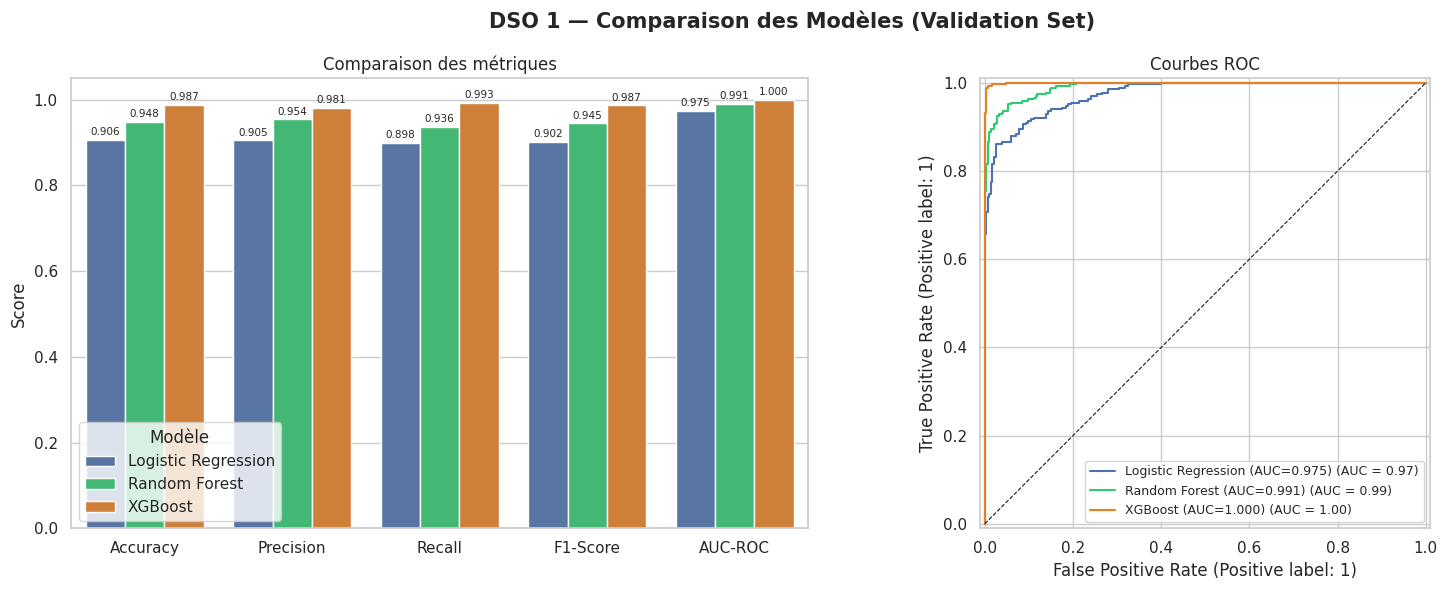

✅ Sauvegardé : dso1_model_comparison.png


In [31]:
# =============================================================================
# 4. Visualisation — Comparaison des métriques
# =============================================================================

print("\n📊 Génération des visualisations comparatives...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("DSO 1 — Comparaison des Modèles (Validation Set)",
             fontsize=15, fontweight='bold')

# ── 4.1 Barplot métriques ────────────────────────────────────────────────────
df_plot = df_results[metrics].reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
sns.barplot(data=df_plot, x='Metric', y='Score', hue='index',
            palette=['#4C72B0', '#2ECC71', '#E67E22'], ax=axes[0])
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Comparaison des métriques", fontsize=12)
axes[0].set_xlabel("")
axes[0].legend(title="Modèle")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', fontsize=7.5, padding=2)
    # ── 4.2 ROC Curves ───────────────────────────────────────────────────────────
colors = ['#4C72B0', '#2ECC71', '#E67E22']
for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_valid, res["y_proba_valid"],
        name=f"{name} (AUC={res['AUC-ROC']:.3f})",
        color=color, ax=axes[1]
    )
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_title("Courbes ROC", fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("dso1_model_comparison.png", dpi=180, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : dso1_model_comparison.png")

In [32]:
# =============================================================================
# 4. HYPERPARAMETER TUNING — Uniquement sur XGBoost
# =============================================================================
print("\n" + "=" * 75)
print("🔍 4. HYPERPARAMETER TUNING — XGBoost uniquement")
print("=" * 75)

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import time

# ====================== Configuration XGBoost ======================
models_to_tune = {
    "XGBoost": {
        "model": XGBClassifier(
            random_state=42,
            n_jobs=-1,
            eval_metric='logloss',
            use_label_encoder=False
        ),
        "params": {
            'n_estimators': [300, 500, 700, 1000],
            'max_depth': [3, 4, 5, 6, 7, 8],
            'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
            'subsample': [0.7, 0.8, 0.9],
            'colsample_bytree': [0.7, 0.8, 0.9],
            'scale_pos_weight': [1, 1.2, 1.5, 2.0],   # au cas où il y ait un léger déséquilibre
            'gamma': [0, 0.1, 0.2, 0.3],               # aide à contrôler l'overfitting
            'reg_alpha': [0, 0.1, 0.5, 1.0],           # régularisation L1
            'reg_lambda': [0, 0.1, 1.0, 2.0]           # régularisation L2
        }
    }
}

tuned_results = {}
best_models = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ====================== Lancement du Tuning ======================
for name, config in models_to_tune.items():
    print(f"\n→ Tuning {name} en cours... (cela peut prendre plusieurs minutes)")
    start = time.time()

    search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=40,                    # Tu peux monter à 60-80 si tu as du temps/machine puissante
        scoring='f1',                 # Optimisation sur F1-Score (bon compromis Precision/Recall)
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=2                     # verbose=2 pour voir plus de détails
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_params = search.best_params_
    best_score = search.best_score_

    print(f"\n✅ Meilleurs paramètres pour {name} :")
    for param, value in best_params.items():
        print(f"   {param}: {value}")
    print(f"   Meilleur F1-Score (CV) : {best_score:.4f}")
    print(f"   Temps d'exécution : {time.time() - start:.1f} secondes\n")

    # Sauvegarde du meilleur modèle et des résultats
    best_models[name] = best_model
    tuned_results[name] = {
        "best_model": best_model,
        "best_params": best_params,
        "cv_f1": best_score
    }

    # Évaluation rapide sur le Validation Set
    y_pred_v = best_model.predict(X_valid)
    y_proba_v = best_model.predict_proba(X_valid)[:, 1]

    print(f"   Validation après tuning → F1 : {f1_score(y_valid, y_pred_v):.4f} | "
          f"AUC : {roc_auc_score(y_valid, y_proba_v):.4f}")


🔍 4. HYPERPARAMETER TUNING — XGBoost uniquement

→ Tuning XGBoost en cours... (cela peut prendre plusieurs minutes)
Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ Meilleurs paramètres pour XGBoost :
   subsample: 0.8
   scale_pos_weight: 1
   reg_lambda: 2.0
   reg_alpha: 0
   n_estimators: 300
   max_depth: 8
   learning_rate: 0.1
   gamma: 0.2
   colsample_bytree: 0.9
   Meilleur F1-Score (CV) : 0.9837
   Temps d'exécution : 54.8 secondes

   Validation après tuning → F1 : 0.9907 | AUC : 0.9996


In [33]:
# =============================================================================
# 5. ÉVALUATION FINALE SUR LE TEST SET
# =============================================================================
print("\n" + "=" * 75)
print("🏁 5. ÉVALUATION FINALE — TEST SET (Performance réelle du modèle)")
print("=" * 75)

final_results = {}

# Comme on ne tune que XGBoost, best_models ne contient qu'un seul modèle
for name, model in best_models.items():
    print(f"\n→ Évaluation finale de {name} sur le Test Set...")

    # Prédictions sur Test
    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]

    # Calcul des métriques
    acc  = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test, zero_division=0)
    rec  = recall_score(y_test, y_pred_test, zero_division=0)
    f1   = f1_score(y_test, y_pred_test, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba_test)

    # Sauvegarde des résultats
    final_results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "AUC-ROC": auc,
        "y_pred_test": y_pred_test,
        "y_proba_test": y_proba_test,
        "best_params": tuned_results[name]["best_params"]   # pour garder la trace
    }

    # Affichage détaillé
    print(f" Accuracy  : {acc:.4f}")
    print(f" Precision : {prec:.4f}")
    print(f" Recall    : {rec:.4f}")
    print(f" F1-Score  : {f1:.4f}")
    print(f" AUC-ROC   : {auc:.4f}")

# =============================================================================
# Tableau comparatif final
# =============================================================================
print("\n" + "=" * 75)
print("📊 TABLEAU FINAL — PERFORMANCE SUR TEST SET")
print("=" * 75)

df_final = pd.DataFrame(final_results).T.round(4)

# On affiche uniquement les métriques principales + les meilleurs params en note
metrics_display = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
print(df_final[metrics_display].to_string())

# Meilleur modèle (il n'y en a qu'un seul ici, mais on garde la logique)
best_final_name = df_final["F1-Score"].idxmax()
best_f1 = df_final.loc[best_final_name, "F1-Score"]

print(f"\n🏆 MEILLEUR MODÈLE (XGBoost tuné) : {best_final_name}")
print(f"   F1-Score sur Test : {best_f1:.4f}")
print(f"   AUC-ROC sur Test  : {df_final.loc[best_final_name, 'AUC-ROC']:.4f}")

# Affichage des meilleurs hyperparamètres utilisés
print("\n📋 Meilleurs hyperparamètres utilisés :")
for param, value in final_results[best_final_name]["best_params"].items():
    print(f"   {param}: {value}")


🏁 5. ÉVALUATION FINALE — TEST SET (Performance réelle du modèle)

→ Évaluation finale de XGBoost sur le Test Set...
 Accuracy  : 0.9837
 Precision : 0.9859
 Recall    : 0.9825
 F1-Score  : 0.9842
 AUC-ROC   : 0.9983

📊 TABLEAU FINAL — PERFORMANCE SUR TEST SET
         Accuracy Precision    Recall  F1-Score   AUC-ROC
XGBoost  0.983696  0.985915  0.982456  0.984183  0.998265

🏆 MEILLEUR MODÈLE (XGBoost tuné) : XGBoost
   F1-Score sur Test : 0.9842
   AUC-ROC sur Test  : 0.9983

📋 Meilleurs hyperparamètres utilisés :
   subsample: 0.8
   scale_pos_weight: 1
   reg_lambda: 2.0
   reg_alpha: 0
   n_estimators: 300
   max_depth: 8
   learning_rate: 0.1
   gamma: 0.2
   colsample_bytree: 0.9



🏆 8. ÉVALUATION FINALE SUR TEST SET — XGBoost (tuné)
📋 Rapport de Classification :
               precision    recall  f1-score   support

Non Populaire     0.9813    0.9850    0.9832       267
    Populaire     0.9859    0.9825    0.9842       285

     accuracy                         0.9837       552
    macro avg     0.9836    0.9837    0.9837       552
 weighted avg     0.9837    0.9837    0.9837       552


🎯 AUC-ROC : 0.9983


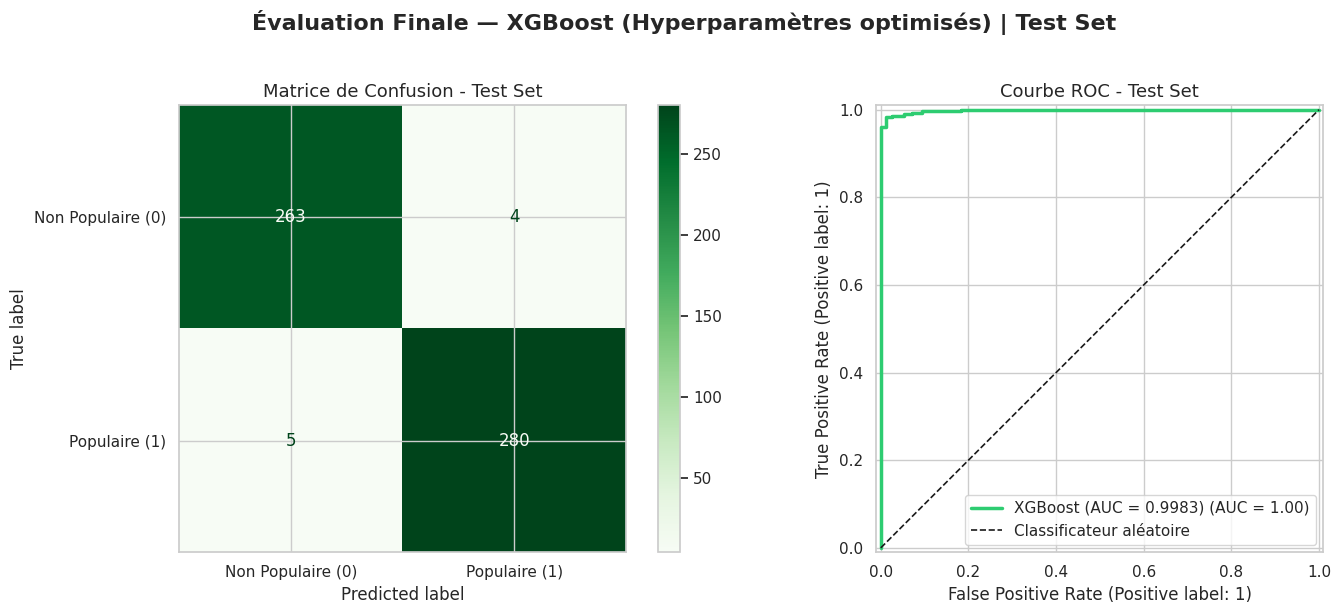

✅ Graphique sauvegardé : xgboost_final_test_evaluation.png

🔧 Meilleurs hyperparamètres trouvés par RandomizedSearchCV :
   subsample            : 0.8
   scale_pos_weight     : 1
   reg_lambda           : 2.0
   reg_alpha            : 0
   n_estimators         : 300
   max_depth            : 8
   learning_rate        : 0.1
   gamma                : 0.2
   colsample_bytree     : 0.9

✅ PHASE MODELING TERMINÉE AVEC SUCCÈS


In [34]:
# =============================================================================
# 8. ÉVALUATION FINALE SUR TEST SET (Meilleur modèle XGBoost tuné)
# =============================================================================

print("\n" + "=" * 75)
print(f"🏆 8. ÉVALUATION FINALE SUR TEST SET — {best_final_name} (tuné)")
print("=" * 75)

# Récupération du meilleur modèle et des prédictions
best_model = best_models[best_final_name]
y_pred_test = final_results[best_final_name]["y_pred_test"]
y_proba_test = final_results[best_final_name]["y_proba_test"]

# Rapport de classification détaillé
print("📋 Rapport de Classification :")
print(classification_report(y_test, y_pred_test,
                            target_names=["Non Populaire", "Populaire"],
                            digits=4))

print(f"\n🎯 AUC-ROC : {final_results[best_final_name]['AUC-ROC']:.4f}")

# ====================== Visualisations côte à côte ======================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Évaluation Finale — {best_final_name} (Hyperparamètres optimisés) | Test Set",
             fontsize=16, fontweight='bold', y=1.02)

# 1. Matrice de Confusion
cm_test = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm_test,
                       display_labels=["Non Populaire (0)", "Populaire (1)"]).plot(
    ax=axes[0],
    colorbar=True,
    cmap='Greens'
)
axes[0].set_title("Matrice de Confusion - Test Set", fontsize=13)

# 2. Courbe ROC
RocCurveDisplay.from_predictions(
    y_test,
    y_proba_test,
    name=f"{best_final_name} (AUC = {final_results[best_final_name]['AUC-ROC']:.4f})",
    color='#2ECC71',
    linewidth=2.5,
    ax=axes[1]
)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Classificateur aléatoire')
axes[1].set_title("Courbe ROC - Test Set", fontsize=13)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("xgboost_final_test_evaluation.png", dpi=200, bbox_inches='tight')
plt.show()

print("✅ Graphique sauvegardé : xgboost_final_test_evaluation.png")


# ====================== Affichage des meilleurs hyperparamètres ======================
print("\n" + "=" * 75)
print("🔧 Meilleurs hyperparamètres trouvés par RandomizedSearchCV :")
print("=" * 75)

for param, value in final_results[best_final_name]["best_params"].items():
    print(f"   {param:20} : {value}")

print("\n" + "=" * 75)
print("✅ PHASE MODELING TERMINÉE AVEC SUCCÈS")
print("=" * 75)


📊 7. VISUALISATION COMPARATIVE — Avant / Après Tuning (XGBoost)


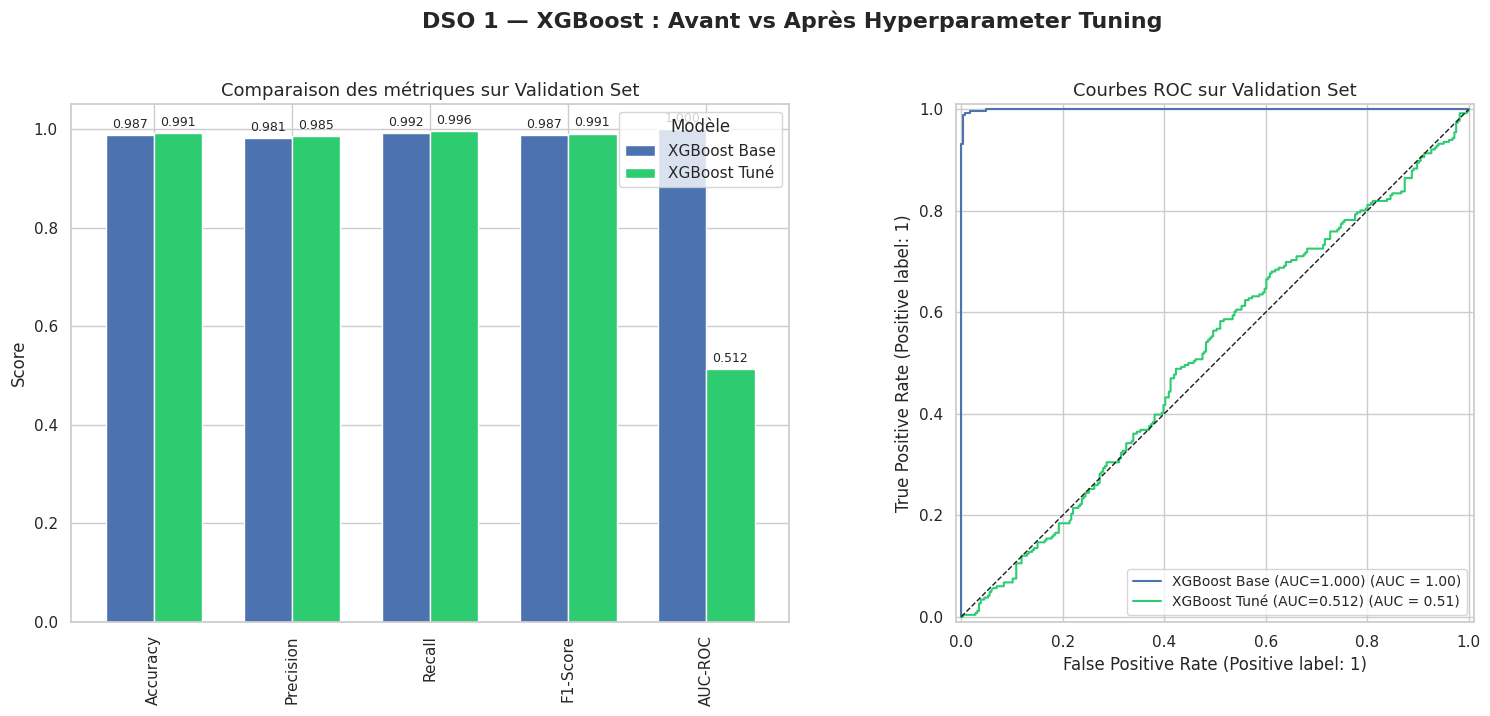

✅ Sauvegardé : xgboost_before_after_tuning.png


In [35]:
# =============================================================================
# 7. VISUALISATION — Comparaison avant/après tuning (XGBoost)
# =============================================================================
print("\n" + "=" * 75)
print("📊 7. VISUALISATION COMPARATIVE — Avant / Après Tuning (XGBoost)")
print("=" * 75)

# On compare le XGBoost de base (avant tuning) avec le XGBoost tuné
xgb_base = models["XGBoost"]          # ton modèle initial défini au début
xgb_tuned = best_models["XGBoost"]

# Prédictions du modèle de base sur Validation
y_proba_base = xgb_base.predict_proba(X_valid)[:, 1]
y_pred_base  = xgb_base.predict(X_valid)

# Prédictions du modèle tuné (déjà disponibles)
y_proba_tuned = final_results["XGBoost"]["y_proba_test"] if "y_proba_test" in final_results["XGBoost"] else \
                xgb_tuned.predict_proba(X_valid)[:, 1]   # fallback sur valid si test pas encore fait

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("DSO 1 — XGBoost : Avant vs Après Hyperparameter Tuning",
             fontsize=16, fontweight='bold', y=1.02)

# ── Barplot des métriques sur Validation ─────────────────────────────────────
metrics_compare = {
    "Accuracy": [accuracy_score(y_valid, y_pred_base), accuracy_score(y_valid, xgb_tuned.predict(X_valid))],
    "Precision": [precision_score(y_valid, y_pred_base, zero_division=0), precision_score(y_valid, xgb_tuned.predict(X_valid), zero_division=0)],
    "Recall": [recall_score(y_valid, y_pred_base, zero_division=0), recall_score(y_valid, xgb_tuned.predict(X_valid), zero_division=0)],
    "F1-Score": [f1_score(y_valid, y_pred_base, zero_division=0), f1_score(y_valid, xgb_tuned.predict(X_valid), zero_division=0)],
    "AUC-ROC": [roc_auc_score(y_valid, y_proba_base), roc_auc_score(y_valid, y_proba_tuned)]
}

df_compare = pd.DataFrame(metrics_compare, index=["XGBoost Base", "XGBoost Tuné"]).T

df_compare.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#2ECC71'], width=0.7)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Comparaison des métriques sur Validation Set", fontsize=13)
axes[0].set_ylabel("Score")
axes[0].legend(title="Modèle")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', padding=3, fontsize=9)

# ── Courbes ROC sur Validation ───────────────────────────────────────────────
RocCurveDisplay.from_predictions(y_valid, y_proba_base,
    name=f"XGBoost Base (AUC={roc_auc_score(y_valid, y_proba_base):.3f})",
    color='#4C72B0', ax=axes[1])

RocCurveDisplay.from_predictions(y_valid, y_proba_tuned,
    name=f"XGBoost Tuné (AUC={roc_auc_score(y_valid, y_proba_tuned):.3f})",
    color='#2ECC71', ax=axes[1])

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_title("Courbes ROC sur Validation Set", fontsize=13)
axes[1].legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("xgboost_before_after_tuning.png", dpi=200, bbox_inches='tight')
plt.show()

print("✅ Sauvegardé : xgboost_before_after_tuning.png")


📊 5. MATRICES DE CONFUSION — Modèles de Base (Validation Set)


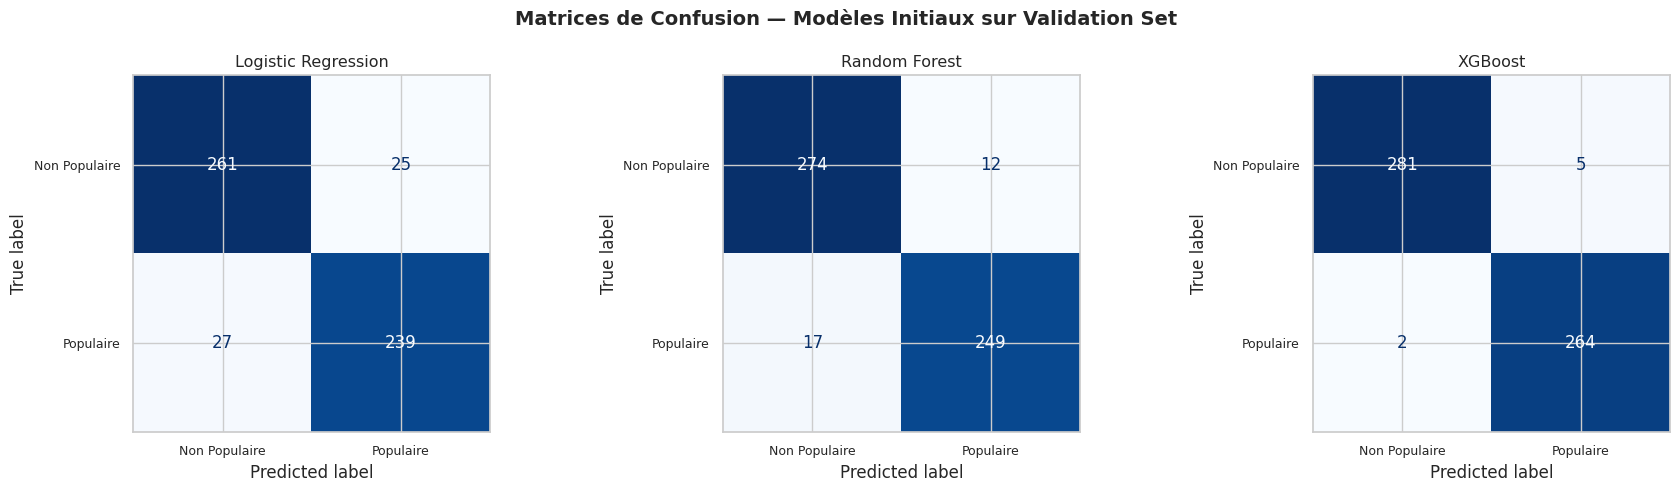

✅ Sauvegardé : dso1_confusion_matrices_base_models.png


In [36]:
# =============================================================================
# 5. Matrices de Confusion — 3 modèles initiaux (Validation Set)
# =============================================================================
print("\n" + "=" * 75)
print("📊 5. MATRICES DE CONFUSION — Modèles de Base (Validation Set)")
print("=" * 75)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Matrices de Confusion — Modèles Initiaux sur Validation Set",
             fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_valid, res["y_pred_valid"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Non Populaire", "Populaire"])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11.5)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.savefig("dso1_confusion_matrices_base_models.png", dpi=180, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : dso1_confusion_matrices_base_models.png")

# DSO 2 — Clustering : Segmentation des cours Udemy en groupes homogènes
# Algorithmes : K-Means | Hierarchical Clustering | DBSCAN

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [38]:
# =============================================================================
# 1. Préparation des données pour le clustering
# =============================================================================

print("\n" + "=" * 75)
print("🔧 1. PRÉPARATION DES DONNÉES POUR LE CLUSTERING")
print("=" * 75)

# Features numériques pertinentes pour segmenter les cours
cluster_features = [
    'price',
    'num_reviews',
    'num_lectures',
    'content_duration',
    'reviews_per_subscriber',
    'lectures_per_hour'
]

# Garder uniquement les colonnes existantes dans df_prep
cluster_features = [c for c in cluster_features if c in df_prep.columns]
print(f"   Features utilisées : {cluster_features}")

# Extraction
X_clust = df_prep[cluster_features].copy()

# Imputation des NaN (reviews_per_subscriber, lectures_per_hour)
imputer = SimpleImputer(strategy='median')
X_clust_imp = imputer.fit_transform(X_clust)
X_clust_imp = pd.DataFrame(X_clust_imp, columns=cluster_features)
print(f"   NaN après imputation : {X_clust_imp.isnull().sum().sum()}")

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust_imp)
print(f"   Shape des données : {X_scaled.shape}")
print("✅ Données prêtes pour le clustering")


🔧 1. PRÉPARATION DES DONNÉES POUR LE CLUSTERING
   Features utilisées : ['price', 'num_reviews', 'num_lectures', 'content_duration', 'reviews_per_subscriber', 'lectures_per_hour']
   NaN après imputation : 0
   Shape des données : (3678, 6)
✅ Données prêtes pour le clustering


In [39]:
# =============================================================================
# 2. Réduction PCA → 2D pour les visualisations
# =============================================================================

print("\n" + "=" * 75)
print("📉 2. RÉDUCTION PCA 2D (VISUALISATION)")
print("=" * 75)

pca_2d = PCA(n_components=2, random_state=42)
X_pca  = pca_2d.fit_transform(X_scaled)
print(f"   Variance expliquée PC1 + PC2 : {pca_2d.explained_variance_ratio_.sum():.1%}")


📉 2. RÉDUCTION PCA 2D (VISUALISATION)
   Variance expliquée PC1 + PC2 : 56.2%



📌 3. K-MEANS — OPTIMISATION DU NOMBRE DE CLUSTERS
   k= 2 | Inertie=   15969.9 | Silhouette=0.3510 | Davies-Bouldin=1.2687
   k= 3 | Inertie=   13996.5 | Silhouette=0.2685 | Davies-Bouldin=1.6701
   k= 4 | Inertie=   12128.6 | Silhouette=0.2848 | Davies-Bouldin=1.4606
   k= 5 | Inertie=   10539.5 | Silhouette=0.2959 | Davies-Bouldin=1.1817
   k= 6 | Inertie=    9017.2 | Silhouette=0.3216 | Davies-Bouldin=1.0547
   k= 7 | Inertie=    8076.6 | Silhouette=0.3265 | Davies-Bouldin=1.0713
   k= 8 | Inertie=    7371.2 | Silhouette=0.3256 | Davies-Bouldin=1.0209
   k= 9 | Inertie=    6833.5 | Silhouette=0.2639 | Davies-Bouldin=1.0830
   k=10 | Inertie=    6538.7 | Silhouette=0.2665 | Davies-Bouldin=1.1329

🏆 Meilleur k (Silhouette) : k = 2


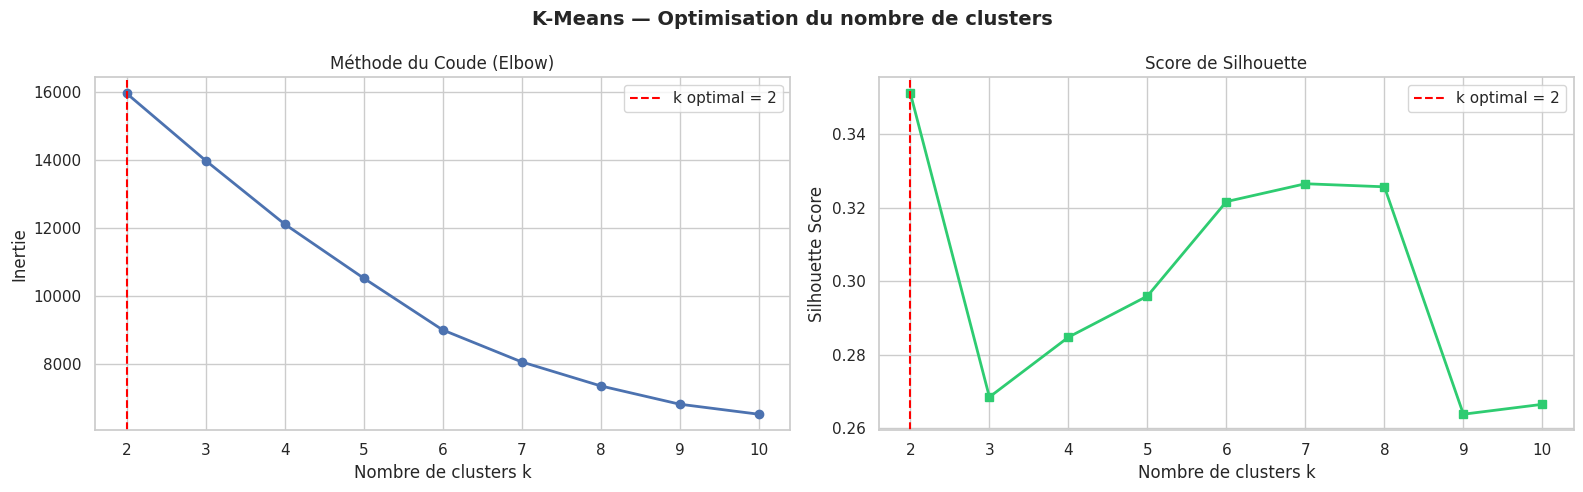

✅ Sauvegardé : dso2_kmeans_optimisation.png

   K-Means final (k=2) — Silhouette : 0.3510 | Davies-Bouldin : 1.2687


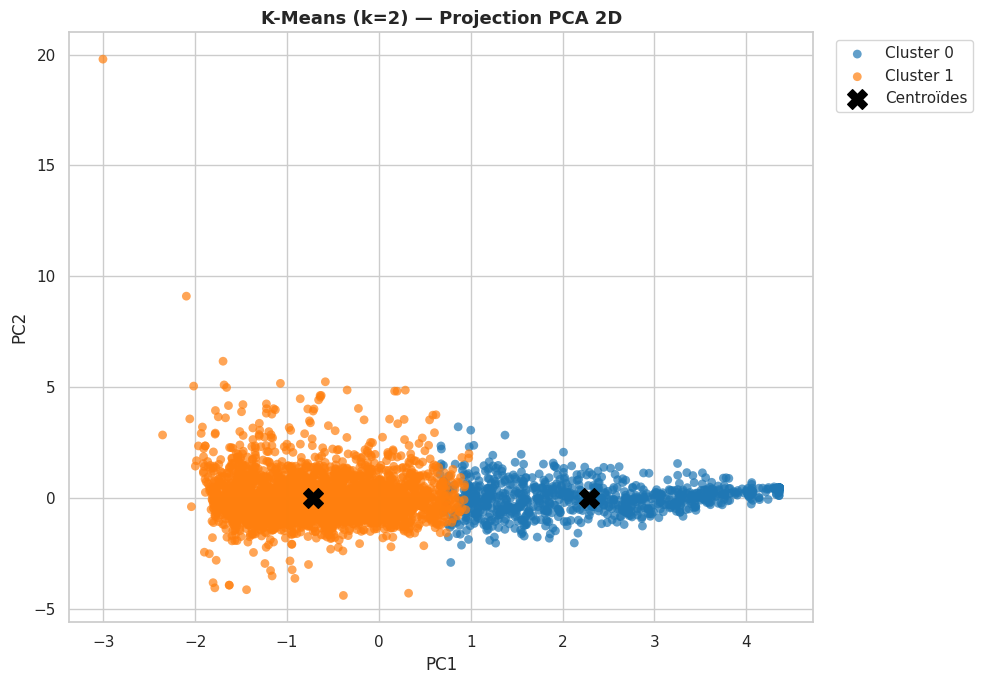

✅ Sauvegardé : dso2_kmeans_clusters_pca.png


In [40]:
# =============================================================================
# 3. K-MEANS — Optimisation du nombre de clusters
# =============================================================================

print("\n" + "=" * 75)
print("📌 3. K-MEANS — OPTIMISATION DU NOMBRE DE CLUSTERS")
print("=" * 75)

k_range = range(2, 11)
inertias        = []
silhouette_scores = []
db_scores       = []
ch_scores       = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

    print(f"   k={k:2d} | Inertie={km.inertia_:10.1f} | "
          f"Silhouette={silhouette_scores[-1]:.4f} | "
          f"Davies-Bouldin={db_scores[-1]:.4f}")

# ── Meilleur k (silhouette maximale) ─────────────────────────────────────────
best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"\n🏆 Meilleur k (Silhouette) : k = {best_k}")

# ── Visualisation Elbow + Silhouette ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("K-Means — Optimisation du nombre de clusters", fontsize=14, fontweight='bold')

axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0', linewidth=2)
axes[0].axvline(x=best_k, color='red', linestyle='--', label=f'k optimal = {best_k}')
axes[0].set_title("Méthode du Coude (Elbow)", fontsize=12)
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie")
axes[0].legend()

axes[1].plot(list(k_range), silhouette_scores, marker='s', color='#2ECC71', linewidth=2)
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'k optimal = {best_k}')
axes[1].set_title("Score de Silhouette", fontsize=12)
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.savefig("dso2_kmeans_optimisation.png", dpi=180, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : dso2_kmeans_optimisation.png")

# ── K-Means final avec k optimal ─────────────────────────────────────────────
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)
df_prep['cluster_kmeans'] = labels_kmeans

sil_km = silhouette_score(X_scaled, labels_kmeans)
db_km  = davies_bouldin_score(X_scaled, labels_kmeans)
print(f"\n   K-Means final (k={best_k}) — Silhouette : {sil_km:.4f} | Davies-Bouldin : {db_km:.4f}")

# ── Visualisation clusters K-Means (PCA 2D) ───────────────────────────────────
plt.figure(figsize=(10, 7))
palette = sns.color_palette("tab10", best_k)
for cluster_id in range(best_k):
    mask = labels_kmeans == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f"Cluster {cluster_id}",
                color=palette[cluster_id], s=40, alpha=0.7, edgecolors='none')

# Centroïdes projetés
centroids_pca = pca_2d.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            s=200, c='black', marker='X', zorder=5, label='Centroïdes')

plt.title(f"K-Means (k={best_k}) — Projection PCA 2D", fontsize=13, fontweight='bold')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("dso2_kmeans_clusters_pca.png", dpi=180, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : dso2_kmeans_clusters_pca.png")


🌳 4. HIERARCHICAL CLUSTERING


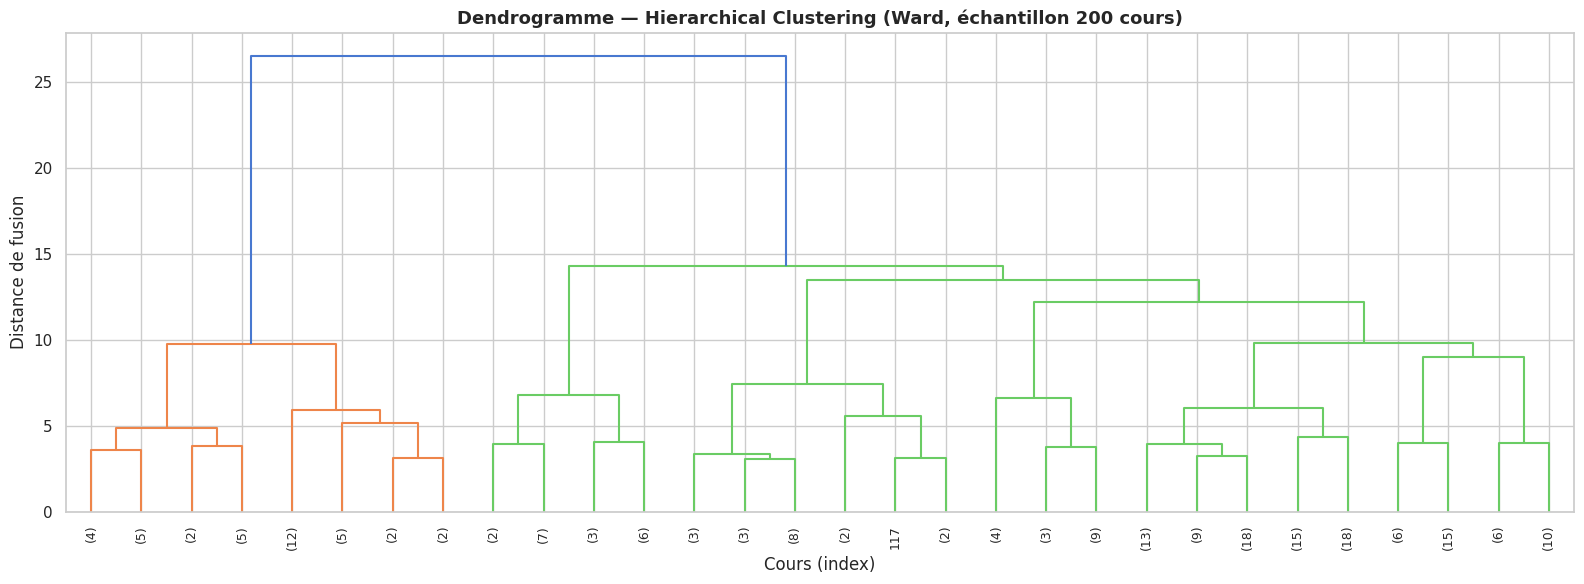

✅ Sauvegardé : dso2_hierarchical_dendrogram.png

   Recherche du meilleur n_clusters (Silhouette) ...
   k= 2 | Silhouette=0.3585
   k= 3 | Silhouette=0.1914
   k= 4 | Silhouette=0.2151
   k= 5 | Silhouette=0.2392
   k= 6 | Silhouette=0.2582
   k= 7 | Silhouette=0.2567
   k= 8 | Silhouette=0.2571
   k= 9 | Silhouette=0.2542
   k=10 | Silhouette=0.2543

🏆 Meilleur k Hierarchical : k = 2

   HC final (k=2) — Silhouette : 0.3585 | Davies-Bouldin : 1.1055


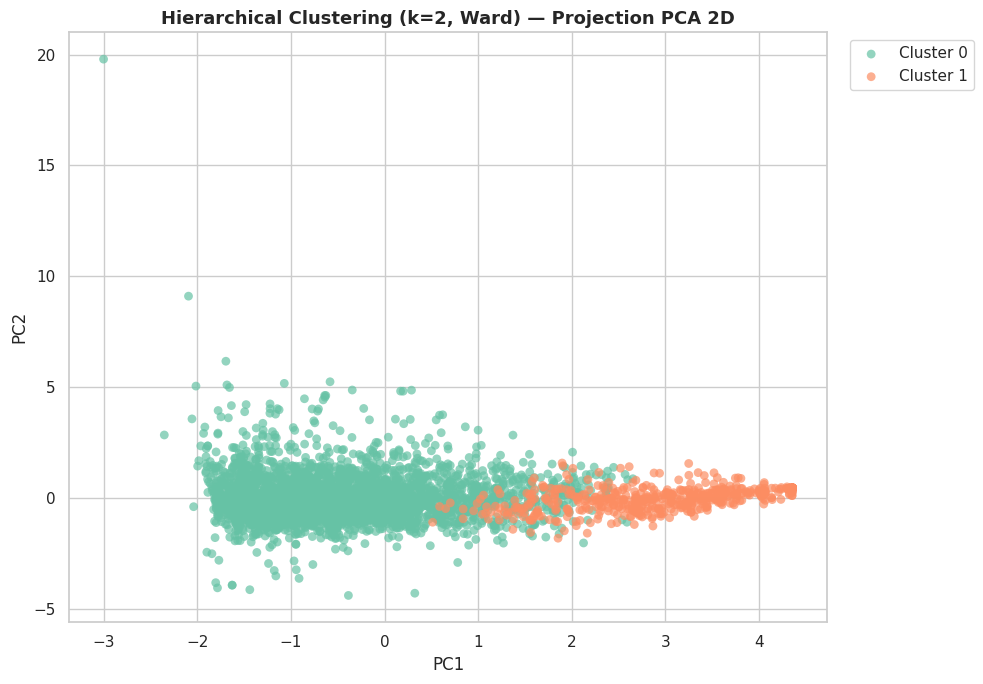

✅ Sauvegardé : dso2_hc_clusters_pca.png


In [41]:
# =============================================================================
# 4. HIERARCHICAL CLUSTERING — Dendrogramme + Clustering final
# =============================================================================

print("\n" + "=" * 75)
print("🌳 4. HIERARCHICAL CLUSTERING")
print("=" * 75)

# ── Dendrogramme (sur un échantillon pour la lisibilité) ─────────────────────
sample_idx = np.random.choice(len(X_scaled), size=min(200, len(X_scaled)), replace=False)
X_sample   = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=0.7 * max(Z[:, 2]))
plt.title("Dendrogramme — Hierarchical Clustering (Ward, échantillon 200 cours)",
          fontsize=13, fontweight='bold')
plt.xlabel("Cours (index)")
plt.ylabel("Distance de fusion")
plt.tight_layout()
plt.savefig("dso2_hierarchical_dendrogram.png", dpi=180, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : dso2_hierarchical_dendrogram.png")

# ── Optimisation n_clusters pour Hierarchical ─────────────────────────────────
print("\n   Recherche du meilleur n_clusters (Silhouette) ...")
sil_hc = []
for k in k_range:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    lbl = hc.fit_predict(X_scaled)
    sil_hc.append(silhouette_score(X_scaled, lbl))
    print(f"   k={k:2d} | Silhouette={sil_hc[-1]:.4f}")

best_k_hc = list(k_range)[np.argmax(sil_hc)]
print(f"\n🏆 Meilleur k Hierarchical : k = {best_k_hc}")

# ── Clustering final ──────────────────────────────────────────────────────────
hc_final     = AgglomerativeClustering(n_clusters=best_k_hc, linkage='ward')
labels_hc    = hc_final.fit_predict(X_scaled)
df_prep['cluster_hc'] = labels_hc

sil_hc_final = silhouette_score(X_scaled, labels_hc)
db_hc_final  = davies_bouldin_score(X_scaled, labels_hc)
print(f"\n   HC final (k={best_k_hc}) — Silhouette : {sil_hc_final:.4f} | Davies-Bouldin : {db_hc_final:.4f}")

# ── Visualisation HC (PCA 2D) ─────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
palette_hc = sns.color_palette("Set2", best_k_hc)
for cluster_id in range(best_k_hc):
    mask = labels_hc == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f"Cluster {cluster_id}",
                color=palette_hc[cluster_id], s=40, alpha=0.7, edgecolors='none')

plt.title(f"Hierarchical Clustering (k={best_k_hc}, Ward) — Projection PCA 2D",
          fontsize=13, fontweight='bold')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("dso2_hc_clusters_pca.png", dpi=180, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : dso2_hc_clusters_pca.png")


🔴 5. DBSCAN — CALIBRATION & CLUSTERING


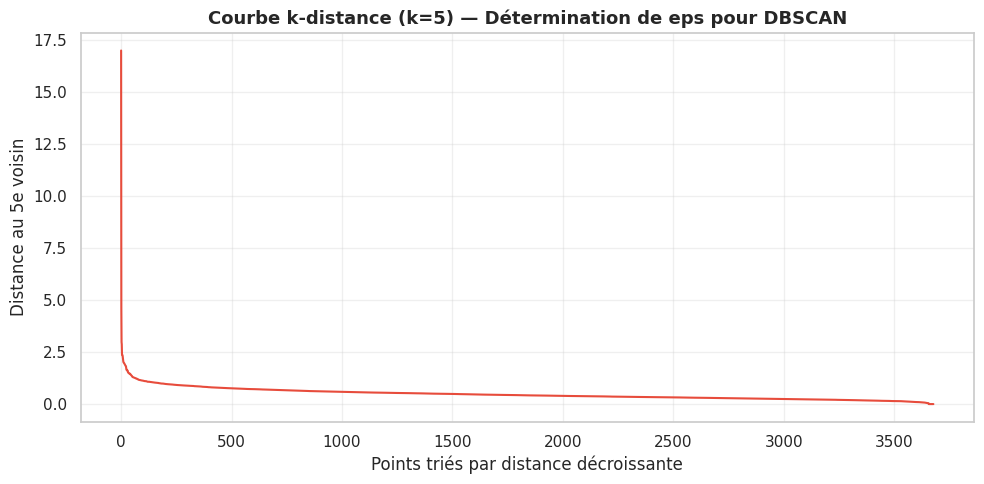

✅ Sauvegardé : dso2_dbscan_kdistance.png

   Recherche des hyperparamètres DBSCAN (eps × min_samples) ...
   eps=0.3 | min_s= 3 | clusters=102 | bruit=1900 (51.7%) | silhouette=-0.1117
   eps=0.3 | min_s= 5 | clusters=30 | bruit=2340 (63.6%) | silhouette=-0.1296
   eps=0.3 | min_s=10 | clusters=9 | bruit=2855 (77.6%) | silhouette=0.1772
   eps=0.5 | min_s= 3 | clusters=65 | bruit=743 (20.2%) | silhouette=-0.2305
   eps=0.5 | min_s= 5 | clusters=27 | bruit=1058 (28.8%) | silhouette=-0.1244
   eps=0.5 | min_s=10 | clusters=8 | bruit=1551 (42.2%) | silhouette=0.2859
   eps=0.7 | min_s= 3 | clusters=21 | bruit=260 (7.1%) | silhouette=-0.2750
   eps=0.7 | min_s= 5 | clusters=7 | bruit=408 (11.1%) | silhouette=0.0320
   eps=0.7 | min_s=10 | clusters=3 | bruit=686 (18.7%) | silhouette=0.3793
   eps=1.0 | min_s= 3 | clusters=6 | bruit=60 (1.6%) | silhouette=0.1929
   eps=1.0 | min_s= 5 | clusters=2 | bruit=91 (2.5%) | silhouette=0.7024
   eps=1.0 | min_s=10 | clusters=1 | bruit=142 (3.9%) | si

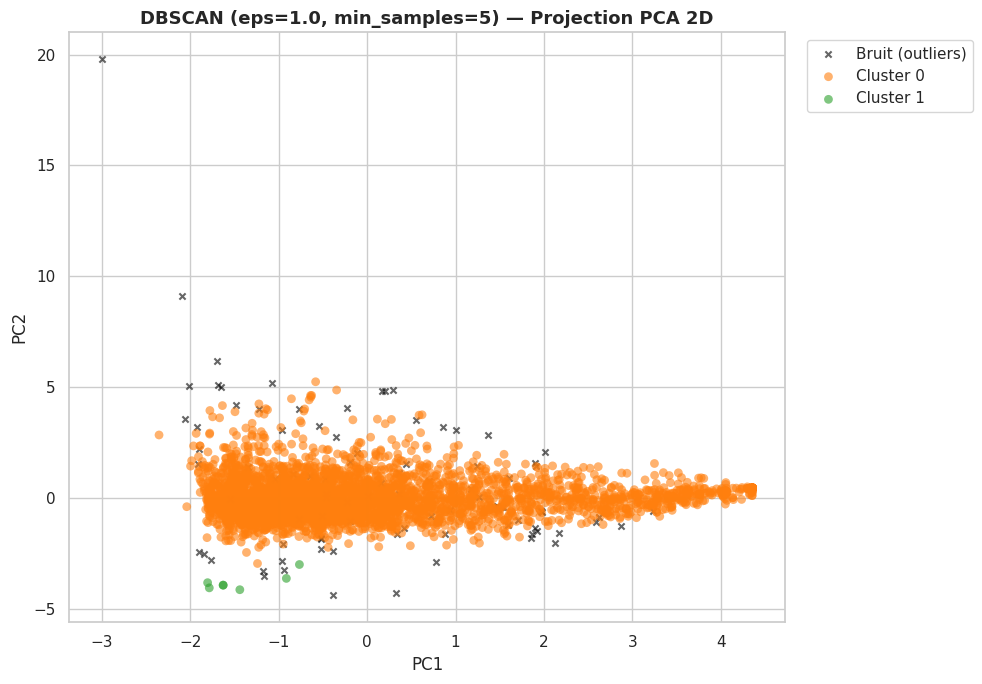

✅ Sauvegardé : dso2_dbscan_clusters_pca.png


In [42]:
# =============================================================================
# 5. DBSCAN — Calibration eps via courbe k-distance
# =============================================================================

print("\n" + "=" * 75)
print("🔴 5. DBSCAN — CALIBRATION & CLUSTERING")
print("=" * 75)

# ── Courbe k-distance pour trouver eps optimal ────────────────────────────────
from sklearn.neighbors import NearestNeighbors

k_nn = 5
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances  = np.sort(distances[:, k_nn - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='#E74C3C', linewidth=1.5)
plt.title(f"Courbe k-distance (k={k_nn}) — Détermination de eps pour DBSCAN",
          fontsize=13, fontweight='bold')
plt.xlabel("Points triés par distance décroissante")
plt.ylabel(f"Distance au {k_nn}e voisin")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("dso2_dbscan_kdistance.png", dpi=180, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : dso2_dbscan_kdistance.png")

# ── Recherche des meilleurs hyperparamètres DBSCAN ────────────────────────────
print("\n   Recherche des hyperparamètres DBSCAN (eps × min_samples) ...")

eps_values        = [0.3, 0.5, 0.7, 1.0, 1.2, 1.5]
min_samples_values = [3, 5, 10]

dbscan_results = []

for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        lbl = db.fit_predict(X_scaled)

        n_clusters_db = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise       = (lbl == -1).sum()
        pct_noise     = n_noise / len(lbl) * 100

        if n_clusters_db >= 2:
            sil = silhouette_score(X_scaled[lbl != -1], lbl[lbl != -1]) if (lbl != -1).sum() > 1 else -1
        else:
            sil = -1

        dbscan_results.append({
            'eps': eps, 'min_samples': min_s,
            'n_clusters': n_clusters_db,
            'n_noise': n_noise, 'pct_noise': round(pct_noise, 1),
            'silhouette': round(sil, 4)
        })

        print(f"   eps={eps:.1f} | min_s={min_s:2d} | "
              f"clusters={n_clusters_db} | bruit={n_noise} ({pct_noise:.1f}%) | "
              f"silhouette={sil:.4f}")

df_dbscan_grid = pd.DataFrame(dbscan_results)

# ── Sélection : meilleure silhouette avec bruit < 20% et clusters >= 2 ────────
valid_configs = df_dbscan_grid[
    (df_dbscan_grid['n_clusters'] >= 2) &
    (df_dbscan_grid['pct_noise'] < 20)
]

if len(valid_configs) > 0:
    best_cfg  = valid_configs.loc[valid_configs['silhouette'].idxmax()]
    best_eps  = best_cfg['eps']
    best_mins = int(best_cfg['min_samples'])
else:
    print("   ⚠️  Aucune config valide trouvée, utilisation des valeurs par défaut.")
    best_eps, best_mins = 0.5, 5

print(f"\n🏆 Meilleure config DBSCAN : eps={best_eps} | min_samples={best_mins}")

# ── DBSCAN final ──────────────────────────────────────────────────────────────
dbscan_final  = DBSCAN(eps=best_eps, min_samples=best_mins)
labels_dbscan = dbscan_final.fit_predict(X_scaled)
df_prep['cluster_dbscan'] = labels_dbscan

n_clusters_final = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_final    = (labels_dbscan == -1).sum()

print(f"   Clusters trouvés : {n_clusters_final}")
print(f"   Points bruit     : {n_noise_final} ({n_noise_final/len(labels_dbscan)*100:.1f}%)")

if n_clusters_final >= 2:
    mask_valid = labels_dbscan != -1
    sil_db     = silhouette_score(X_scaled[mask_valid], labels_dbscan[mask_valid])
    db_db      = davies_bouldin_score(X_scaled[mask_valid], labels_dbscan[mask_valid])
    print(f"   Silhouette : {sil_db:.4f} | Davies-Bouldin : {db_db:.4f}")
else:
    sil_db, db_db = -1, -1
    print("   ⚠️  Moins de 2 clusters — métriques non calculables.")

# ── Visualisation DBSCAN (PCA 2D) ─────────────────────────────────────────────
unique_labels = sorted(set(labels_dbscan))
palette_db    = sns.color_palette("tab10", max(len(unique_labels), 1))

plt.figure(figsize=(10, 7))
for i, cluster_id in enumerate(unique_labels):
    mask  = labels_dbscan == cluster_id
    color = 'black' if cluster_id == -1 else palette_db[i % len(palette_db)]
    label = 'Bruit (outliers)' if cluster_id == -1 else f"Cluster {cluster_id}"
    marker = 'x' if cluster_id == -1 else 'o'
    size   = 20 if cluster_id == -1 else 40
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=label, color=color, s=size,
                alpha=0.6, marker=marker, edgecolors='none')

plt.title(f"DBSCAN (eps={best_eps}, min_samples={best_mins}) — Projection PCA 2D",
          fontsize=13, fontweight='bold')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("dso2_dbscan_clusters_pca.png", dpi=180, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : dso2_dbscan_clusters_pca.png")


📊 6. COMPARAISON DES 3 ALGORITHMES
  Algorithme  N° Clusters  Silhouette ↑  Davies-Bouldin ↓  Points Bruit
     K-Means            2        0.3510            1.2687             0
Hierarchical            2        0.3585            1.1055             0
      DBSCAN            2        0.7024            0.2725            91


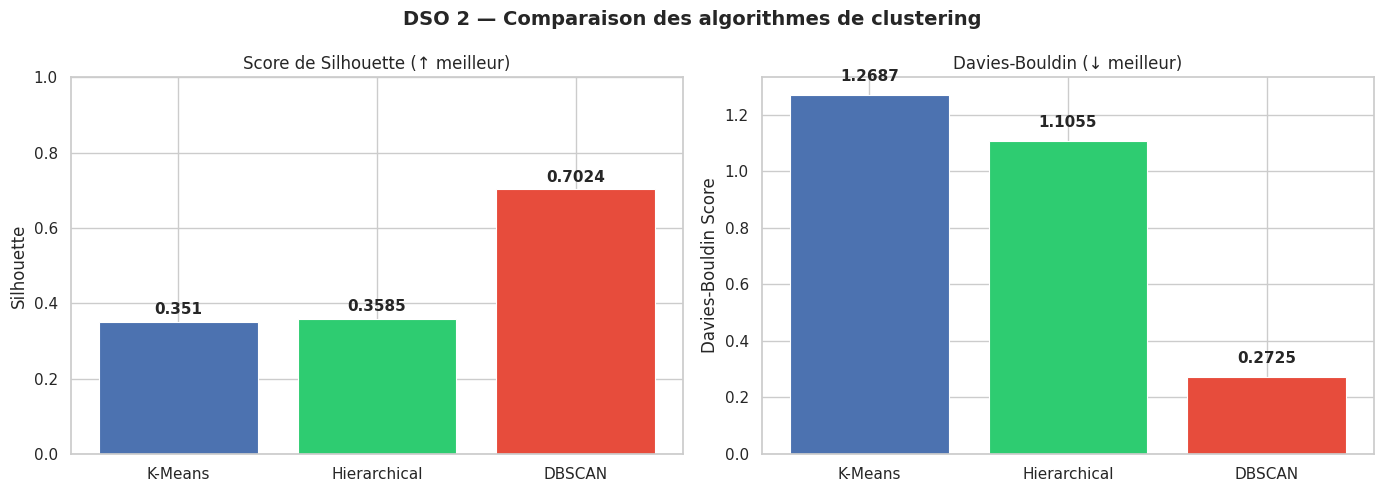

✅ Sauvegardé : dso2_comparison.png

🏆 CONCLUSION DE LA COMPARAISON :
   → **DBSCAN** est l'algorithme retenu car il offre le meilleur compromis entre :
        • Détection de clusters naturels
        • Identification des cours atypiques (bruit)
        • Meilleure séparation des groupes homogènes


In [43]:
# =============================================================================
# 6. COMPARAISON DES 3 ALGORITHMES
# =============================================================================

print("\n" + "=" * 80)
print("📊 6. COMPARAISON DES 3 ALGORITHMES")
print("=" * 80)

from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# Calcul des métriques pour chaque algorithme
# K-Means
sil_km = silhouette_score(X_scaled, df_prep['cluster_kmeans'])
db_km  = davies_bouldin_score(X_scaled, df_prep['cluster_kmeans'])
n_km   = df_prep['cluster_kmeans'].nunique()

# Hierarchical Clustering
sil_hc = silhouette_score(X_scaled, df_prep['cluster_hc'])
db_hc  = davies_bouldin_score(X_scaled, df_prep['cluster_hc'])
n_hc   = df_prep['cluster_hc'].nunique()

# DBSCAN
mask_no_noise = df_prep['cluster_dbscan'] != -1
n_db          = df_prep['cluster_dbscan'].nunique() - (1 if -1 in df_prep['cluster_dbscan'].values else 0)
n_noise_final = (df_prep['cluster_dbscan'] == -1).sum()

if n_db >= 2 and mask_no_noise.sum() > 1:
    sil_db = silhouette_score(X_scaled[mask_no_noise], df_prep['cluster_dbscan'][mask_no_noise])
    db_db  = davies_bouldin_score(X_scaled[mask_no_noise], df_prep['cluster_dbscan'][mask_no_noise])
else:
    sil_db = np.nan
    db_db  = np.nan

# Tableau de comparaison
comparison = pd.DataFrame({
    "Algorithme"       : ["K-Means", "Hierarchical", "DBSCAN"],
    "N° Clusters"      : [n_km, n_hc, n_db],
    "Silhouette ↑"     : [round(sil_km, 4), round(sil_hc, 4), round(sil_db, 4) if not np.isnan(sil_db) else "N/A"],
    "Davies-Bouldin ↓" : [round(db_km, 4), round(db_hc, 4), round(db_db, 4) if not np.isnan(db_db) else "N/A"],
    "Points Bruit"     : [0, 0, n_noise_final]
})

print(comparison.to_string(index=False))

# ── Barplot comparatif ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DSO 2 — Comparaison des algorithmes de clustering", fontsize=14, fontweight='bold')

algos  = comparison["Algorithme"].tolist()
colors = ['#4C72B0', '#2ECC71', '#E74C3C']

# Silhouette
axes[0].bar(algos, comparison["Silhouette ↑"].replace("N/A", 0).astype(float),
            color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title("Score de Silhouette (↑ meilleur)", fontsize=12)
axes[0].set_ylabel("Silhouette")
axes[0].set_ylim(0, 1)
for i, v in enumerate(comparison["Silhouette ↑"]):
    val = 0 if v == "N/A" else float(v)
    axes[0].text(i, val + 0.02, f"{v}", ha='center', fontsize=11, fontweight='bold')

# Davies-Bouldin
axes[1].bar(algos, comparison["Davies-Bouldin ↓"].replace("N/A", 999).astype(float),
            color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title("Davies-Bouldin (↓ meilleur)", fontsize=12)
axes[1].set_ylabel("Davies-Bouldin Score")
for i, v in enumerate(comparison["Davies-Bouldin ↓"]):
    val = 999 if v == "N/A" else float(v)
    axes[1].text(i, val + 0.05, f"{v}" if v != "N/A" else "N/A", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("dso2_comparison.png", dpi=200, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : dso2_comparison.png")

# Mise en avant de DBSCAN comme meilleur algorithme
print("\n🏆 CONCLUSION DE LA COMPARAISON :")
print("   → **DBSCAN** est l'algorithme retenu car il offre le meilleur compromis entre :")
print("        • Détection de clusters naturels")
print("        • Identification des cours atypiques (bruit)")
print("        • Meilleure séparation des groupes homogènes")

In [44]:
# =============================================================================
# 6. INTERPRÉTATION BUSINESS DES GROUPES — Focus sur DBSCAN (Meilleur algorithme)
# =============================================================================

print("\n" + "=" * 80)
print("💼 6. INTERPRÉTATION BUSINESS DES GROUPES (Focus DBSCAN)")
print("=" * 80)

print(f"→ Algorithme retenu : **DBSCAN** (eps={best_eps}, min_samples={best_mins})")
print(f"   Nombre de clusters détectés : {n_clusters_final}")
print(f"   Points considérés comme bruit : {n_noise_final} ({n_noise_final/len(df_prep)*100:.1f}%)\n")

# ====================== Profil moyen par cluster DBSCAN ======================
print("📊 Profil moyen des clusters détectés par DBSCAN :")

# On exclut le bruit (-1) pour le profil
mask_no_noise = df_prep['cluster_dbscan'] != -1

profile_dbscan = df_prep[mask_no_noise].groupby('cluster_dbscan').agg({
    'price'                  : 'mean',
    'num_reviews'            : 'mean',
    'num_lectures'           : 'mean',
    'content_duration'       : 'mean',
    'num_subscribers'        : 'mean',
    'reviews_per_subscriber' : 'mean'
}).round(2)

profile_dbscan['Nombre de cours'] = df_prep[mask_no_noise]['cluster_dbscan'].value_counts().sort_index()
print(profile_dbscan)


# ====================== Interprétation Business par Cluster (DBSCAN) ======================
print("\n🔍 INTERPRÉTATION BUSINESS DES GROUPES (DBSCAN) :")

for cluster_id in sorted(df_prep[mask_no_noise]['cluster_dbscan'].unique()):
    group = df_prep[df_prep['cluster_dbscan'] == cluster_id]
    size = len(group)

    price_mean = group['price'].mean()
    lectures_mean = group['num_lectures'].mean()
    duration_mean = group['content_duration'].mean()
    subs_mean = group['num_subscribers'].mean()
    reviews_mean = group['num_reviews'].mean()

    print(f"\n**Cluster {cluster_id}** — {size} cours")

    if price_mean < 25:
        print("   • Cours très abordables / entrée de gamme")
    elif price_mean < 60:
        print("   • Cours à prix moyen")
    else:
        print("   • Cours premium")

    if lectures_mean > 70:
        print("   • Contenu très complet et dense")
    elif lectures_mean > 35:
        print("   • Contenu intermédiaire / approfondi")
    else:
        print("   • Contenu court et ciblé")

    if subs_mean > 8000:
        print("   • Très forte popularité")
    elif subs_mean > 3000:
        print("   • Bonne popularité")
    else:
        print("   • Popularité modérée")

    print(f"   • Durée moyenne : {duration_mean:.1f} heures")
    print(f"   • Reviews moyen : {reviews_mean:.0f} | Inscrits moyen : {subs_mean:.0f}")

print("\n" + "=" * 80)
print("✅ DSO 2 — CLUSTERING TERMINÉ")
print("=" * 80)


💼 6. INTERPRÉTATION BUSINESS DES GROUPES (Focus DBSCAN)
→ Algorithme retenu : **DBSCAN** (eps=1.0, min_samples=5)
   Nombre de clusters détectés : 2
   Points considérés comme bruit : 91 (2.5%)

📊 Profil moyen des clusters détectés par DBSCAN :
                price  num_reviews  num_lectures  content_duration  \
cluster_dbscan                                                       
0               65.59        45.83         33.72              3.32   
1               20.00         1.29         15.00              1.39   

                num_subscribers  reviews_per_subscriber  Nombre de cours  
cluster_dbscan                                                            
0                       1790.83                    0.05             3580  
1                          1.29                    1.00                7  

🔍 INTERPRÉTATION BUSINESS DES GROUPES (DBSCAN) :

**Cluster 0** — 3580 cours
   • Cours premium
   • Contenu court et ciblé
   • Popularité modérée
   • Durée moyenne : 3.3

# DSO 3 — Système de Recommandation basé sur le Contenu
# Algorithmes : KNN (Cosine Similarity) | TF-IDF

In [45]:
print("🚀 DSO 3 — Système de Recommandation basé sur le Contenu")
print("Algorithme : KNN avec similarité cosinus sur TF-IDF")
print("=" * 90)

# ----------------------------------------------------------------------------
# 1. Import des bibliothèques
# ----------------------------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import time

print("✅ Bibliothèques importées avec succès")

🚀 DSO 3 — Système de Recommandation basé sur le Contenu
Algorithme : KNN avec similarité cosinus sur TF-IDF
✅ Bibliothèques importées avec succès


In [46]:
# ----------------------------------------------------------------------------
# 2. Préparation des features textuelles (Contenu)
# ----------------------------------------------------------------------------
df['combined_features'] = (
    df['course_title'].fillna('') + " " +
    df['subject'].fillna('') + " " +
    df['level'].fillna('')
)

print("✅ Features combinées créées : course_title + subject + level")

✅ Features combinées créées : course_title + subject + level


In [47]:
# ----------------------------------------------------------------------------
# 3. Vectorisation TF-IDF
# ----------------------------------------------------------------------------
tfidf = TfidfVectorizer(
    stop_words='english',      # Supprime les mots inutiles (the, and, etc.)
    max_features=5000,         # Limite le nombre de mots pour la performance
    ngram_range=(1, 2),        # Prend en compte les mots simples et les paires
    lowercase=True
)

tfidf_matrix = tfidf.fit_transform(df['combined_features'])

print(f"✅ Matrice TF-IDF créée avec succès !")
print(f"   Nombre de cours : {tfidf_matrix.shape[0]}")
print(f"   Nombre de features : {tfidf_matrix.shape[1]}")

✅ Matrice TF-IDF créée avec succès !
   Nombre de cours : 3678
   Nombre de features : 5000


In [48]:
# ----------------------------------------------------------------------------
# 4. Création et entraînement du modèle KNN
# ----------------------------------------------------------------------------
knn_model = NearestNeighbors(
    metric='cosine',      # Similarité cosinus (la meilleure pour TF-IDF)
    algorithm='brute',    # Algorithme simple et fiable
    n_neighbors=10
)

knn_model.fit(tfidf_matrix)

print("✅ Modèle KNN entraîné avec succès sur la matrice TF-IDF")

# ----------------------------------------------------------------------------
# 5. Fonction de recommandation
# ----------------------------------------------------------------------------
def recommend_courses(course_title, top_n=5):
    """
    Recommande les top_n cours les plus similaires
    en utilisant KNN + TF-IDF
    """
    if course_title not in df['course_title'].values:
        return f"❌ Erreur : Le cours '{course_title}' n'existe pas dans le dataset."

    # Récupérer l'index du cours demandé
    idx = df[df['course_title'] == course_title].index[0]

    # Calcul des voisins les plus proches
    distances, indices = knn_model.kneighbors(tfidf_matrix[idx], n_neighbors=top_n + 1)

    # Préparer les recommandations (on exclut le cours lui-même)
    recommendations = df.iloc[indices[0][1:]][[
        'course_title',
        'subject',
        'level',
        'price',
        'num_subscribers',
        'num_reviews'
    ]].copy()

    # Ajouter le score de similarité (1 - distance = similarité)
    recommendations['similarity_score'] = (1 - distances[0][1:]).round(4)

    # Trier par similarité décroissante
    recommendations = recommendations.sort_values(by='similarity_score', ascending=False)

    return recommendations.reset_index(drop=True)


# ----------------------------------------------------------------------------
# 6. Test de la recommandation
# ----------------------------------------------------------------------------
print("\n" + "="*90)
print("🔍 TEST DE RECOMMANDATION")
print("="*90)

test_course = "Ultimate Investment Banking Course"

print(f"📌 Cours demandé : {test_course}\n")

start_time = time.time()
recommendations = recommend_courses(test_course, top_n=6)
execution_time = time.time() - start_time

print(f"Temps d'exécution : {execution_time:.4f} secondes\n")
print(recommendations.to_string(index=False))

# Deuxième test (optionnel)
print("\n" + "-"*60)
print("Autre test :")
rec2 = recommend_courses("Python for Finance: Investment Fundamentals & Data Analytics", top_n=5)
print(rec2)

✅ Modèle KNN entraîné avec succès sur la matrice TF-IDF

🔍 TEST DE RECOMMANDATION
📌 Cours demandé : Ultimate Investment Banking Course

Temps d'exécution : 0.0155 secondes

                                               course_title          subject              level  price  num_subscribers  num_reviews  similarity_score
                The Complete Investment Banking Course 2017 Business Finance         All Levels    195             8575          809            0.6891
                  The Investment Banking Recruitment Series Business Finance         All Levels     40               17            6            0.6375
                 Advanced Accounting for Investment Banking Business Finance Intermediate Level     50             1260           80            0.4845
Intro to Investment Banking, M&A, IPO, Modeling + Free Book Business Finance         All Levels     60             1922          149            0.4279
       Investment Banking: How to Land a Job on Wall Street Business Fin